# 0. Carga de librerias

In [20]:
import pandas as pd 
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import math
import warnings
warnings.filterwarnings("ignore")
from rdkit import Chem
from rdkit.Chem import Descriptors
from tqdm import tqdm
from mordred import Calculator, descriptors
from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold,StratifiedGroupKFold,
                                     GridSearchCV)
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               ExtraTreesClassifier, AdaBoostClassifier)
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score,roc_curve, auc, f1_score,
                              matthews_corrcoef, confusion_matrix,
                              classification_report, precision_score,
                              recall_score, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance
from sklearn.neighbors import NearestNeighbors

OUTPUT_DIR_AD   = "resultados dominio de aplicabilidad mordred"
OUTPUT_DIR_ML   = "resultados modelos ML"
OUTPUT_DIR_INT = "resultados interpretabilidad Mordred"
FIGURAS = "figuras/mordred"

# 1. Carga del dataset

In [21]:
df_final = pd.read_csv("Merge_ChEMBL_gallinamides.csv")

## 1.1 Calculo de los descriptores fisicoquimicos a partir de los SMILES etiquetados anteriormente

In [22]:
mols, valid_idx = [], []

print("Convirtiendo SMILES a objetos moleculares...")
for i, row in df_final.iterrows():
    mol = Chem.MolFromSmiles(row["smiles_std"])
    if mol is not None:
        mols.append(mol)
        valid_idx.append(i)
df_mol = df_final.iloc[valid_idx].reset_index(drop=True)
print(f"Moléculas válidas para Mordred: {len(mols)}")

calc = Calculator(descriptors, ignore_3D=True)
print("Calculando descriptores 2D (esto puede tardar varios minutos)...")
df_desc = calc.pandas(mols)
print(f"Descriptores calculados inicialmente: {df_desc.shape[1]}")

Convirtiendo SMILES a objetos moleculares...
Moléculas válidas para Mordred: 470
Calculando descriptores 2D (esto puede tardar varios minutos)...


 27%|██▋       | 129/470 [00:06<00:24, 14.11it/s]

c:\Users\angel\miniconda3\envs\tfm\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 29%|██▉       | 136/470 [00:07<00:21, 15.75it/s]

c:\Users\angel\miniconda3\envs\tfm\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\angel\miniconda3\envs\tfm\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\angel\miniconda3\envs\tfm\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\angel\miniconda3\envs\tfm\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\angel\miniconda3\envs\tfm\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\angel\miniconda3\envs\tfm\lib\site-packages\nu

...

c:\Users\angel\miniconda3\envs\tfm\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 79%|███████▊  | 369/470 [00:17<00:03, 29.01it/s]

c:\Users\angel\miniconda3\envs\tfm\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


100%|██████████| 470/470 [00:20<00:00, 23.21it/s]


Descriptores calculados inicialmente: 1613


## 1.2 Limpieza de descriptores

In [23]:
# Columnas vacias
df_desc = df_desc.dropna(axis=1, how="all")
# Columnas con >20% NaN
thresh = int(len(df_desc) * 0.8)
df_desc = df_desc.dropna(axis=1, thresh=thresh)
# Solo columnas numericas
df_desc = df_desc.select_dtypes(include=[np.number])
# Imputar NaN restantes con mediana
imputer_init = SimpleImputer(strategy="median")
X_arr = imputer_init.fit_transform(df_desc)
X_full = pd.DataFrame(X_arr, columns=df_desc.columns)
# Varianza cero
vt = VarianceThreshold(threshold=0.0)
X_full = pd.DataFrame(
    vt.fit_transform(X_full),
    columns=X_full.columns[vt.get_support()]
)
y = df_mol["Label_FP2"].values
print(f"Descriptores tras limpieza: {X_full.shape[1]}")

X_out = X_full.copy()
X_out.insert(0, "smiles_std", df_mol["smiles_std"].values)
X_out["Label_FP2"] = y
X_out.to_csv(f'{OUTPUT_DIR_ML}/df_descriptores.csv', index=False)
print(f"✅ paso4_descriptores_mordred.csv guardado.")

Descriptores tras limpieza: 1207
✅ paso4_descriptores_mordred.csv guardado.


## 1.3 Separación del dataset en conjuntos

In [24]:
def correlation_filter(X: pd.DataFrame, threshold: float,
                        method: str = "pearson") -> list:
    corr_matrix = X.corr(method=method).abs()
    upper= corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
                             )
    to_drop = {col for col in upper.columns if any(upper[col] >= threshold)}
    retained = [col for col in X.columns if col not in to_drop]
    return retained
    
feature_sets = {}   # {"nombre": [lista_columnas_retenidas]}

CORR_THRESHOLDS   = [0.7, 0.8, 0.9]

for thr in CORR_THRESHOLDS:
    for method in ["pearson", "spearman"]:
        key = f"{method}_thr{thr}"
        retained = correlation_filter(X_full, thr, method)
        feature_sets[key] = retained
        print(f"  {key:30s} → {len(retained):4d} descriptores retenidos")

feature_sets["no_filter"] = list(X_full.columns)
print(f"  {'no_filter':30s} → {len(X_full.columns):4d} descriptores (sin filtro)")

pd.DataFrame(
    {"feature_set": list(feature_sets.keys()),
     "n_features":  [len(v) for v in feature_sets.values()]}
).to_csv(f'{OUTPUT_DIR_ML}/paso5_feature_sets.csv', index=False)
print(f"✅ paso5_feature_sets.csv guardado.", sep=';')

  pearson_thr0.7                 →  149 descriptores retenidos
  spearman_thr0.7                →  154 descriptores retenidos
  pearson_thr0.8                 →  252 descriptores retenidos
  spearman_thr0.8                →  258 descriptores retenidos
  pearson_thr0.9                 →  443 descriptores retenidos
  spearman_thr0.9                →  389 descriptores retenidos
  no_filter                      → 1207 descriptores (sin filtro)
✅ paso5_feature_sets.csv guardado.


## 1.4 Desarrollo de los modelos e hiperparámetros

In [25]:
groups_all = X_full.round(6).apply(lambda r: hash(tuple(r)), axis=1)

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = next(sgkf.split(X_full, y, groups=groups_all))

X_train_full = X_full.iloc[train_idx].reset_index(drop=True)
X_test_full  = X_full.iloc[test_idx].reset_index(drop=True)
y_train      = pd.Series(y).iloc[train_idx].reset_index(drop=True)
y_test       = pd.Series(y).iloc[test_idx].reset_index(drop=True)

print(f"Train: {len(y_train)} muestras | Test: {len(y_test)} muestras")
print(f"  Train activos: {y_train.sum()} ({y_train.mean():.1%})")
print(f"  Test  activos: {y_test.sum()} ({y_test.mean():.1%})")
 
# ── 6.2 Definición de modelos y rejillas de hiperparámetros ───────────────────
# Cada elemento: (nombre, estimador, param_grid)
# Los parámetros del pipeline se prefiján con 'clf__'
 
MODEL_DEFINITIONS = [
    # 1. Regresión Logística
    (
        "LogisticRegression",
        LogisticRegression(max_iter=1000, random_state=42),
        {
            "clf__C"      : [0.01, 0.1, 1, 10, 100],
            "clf__solver" : ["lbfgs", "liblinear"],
            "clf__penalty": ["l2"],
        }
    ),
    # 2. SVM con kernel RBF
    (
        "SVM_RBF",
        SVC(kernel="rbf", probability=True, random_state=42),
        {
            "clf__C"    : [0.1, 1, 10, 100],
            "clf__gamma": ["scale", "auto", 0.001, 0.01],
        }
    ),
    # 3. SVM lineal
    (
        "SVM_Linear",
        SVC(kernel="linear", probability=True, random_state=42),
        {"clf__C": [0.01, 0.1, 1, 10]}
    ),
    # 4. K-Nearest Neighbors
    (
        "KNeighbors",
        KNeighborsClassifier(),
        {
            "clf__n_neighbors": [3, 5, 7, 11, 15],
            "clf__weights"    : ["uniform", "distance"],
            "clf__metric"     : ["euclidean", "manhattan"],
        }
    ),
    # 5. Árbol de decisión
    (
        "DecisionTree",
        DecisionTreeClassifier(random_state=42),
        {
            "clf__max_depth"       : [3, 5, 7, 10, None],
            "clf__min_samples_split": [2, 5, 10],
            "clf__criterion"       : ["gini", "entropy"],
        }
    ),
    # 6. Random Forest
    (
        "RandomForest",
        RandomForestClassifier(random_state=42, n_jobs=-1),
        {
            "clf__n_estimators"    : [100, 200, 300],
            "clf__max_depth"       : [5, 10, 20, None],
            "clf__min_samples_split": [2, 5],
            "clf__max_features"    : ["sqrt", "log2"],
        }
    ),
    # 7. Extra Trees
    (
        "ExtraTrees",
        ExtraTreesClassifier(random_state=42, n_jobs=-1),
        {
            "clf__n_estimators"    : [100, 200, 300],
            "clf__max_depth"       : [5, 10, None],
            "clf__min_samples_split": [2, 5],
        }
    ),
    # 8. Gradient Boosting
    (
        "GradientBoosting",
        GradientBoostingClassifier(random_state=42),
        {
            "clf__n_estimators" : [100, 200],
            "clf__learning_rate": [0.05, 0.1, 0.2],
            "clf__max_depth"    : [3, 5, 7],
        }
    ),
    # 9. AdaBoost
    (
        "AdaBoost",
        AdaBoostClassifier(random_state=42, algorithm="SAMME"),
        {
            "clf__n_estimators" : [50, 100, 200],
            "clf__learning_rate": [0.5, 1.0, 2.0],
        }
    ),
    # 10. Red neuronal (MLP)
    (
        "MLP",
        MLPClassifier(max_iter=500, random_state=42),
        {
            "clf__hidden_layer_sizes": [(64,), (128,), (64, 32), (128, 64)],
            "clf__alpha"             : [1e-4, 1e-3, 1e-2],
            "clf__activation"        : ["relu", "tanh"],
        }
    ),
    # 11. Naive Bayes
    (
        "NaiveBayes",
        GaussianNB(),
        {"clf__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]}
    ),
    # 12. SGD Classifier
    (
        "SGD",
        SGDClassifier(loss="modified_huber", random_state=42,
                      max_iter=1000),
        {
            "clf__alpha"  : [1e-5, 1e-4, 1e-3, 1e-2],
            "clf__penalty": ["l2", "elasticnet"],
        }
    ),

    (
        "XGBoost",
        XGBClassifier(random_state=42, eval_metric="logloss",
                      use_label_encoder=False, n_jobs=-1),
        {
            "clf__n_estimators" : [100, 200, 300],
            "clf__max_depth"    : [3, 5, 7],
            "clf__learning_rate": [0.05, 0.1, 0.2],
            "clf__subsample"    : [0.8, 1.0],
        }
    ),

    (
        "LightGBM",
        LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
        {
            "clf__n_estimators" : [100, 200, 300],
            "clf__num_leaves"   : [31, 63, 127],
            "clf__learning_rate": [0.05, 0.1, 0.2],
        }
    )
]

Train: 378 muestras | Test: 92 muestras
  Train activos: 133 (35.2%)
  Test  activos: 34 (37.0%)


In [26]:
def evaluate(model, X_tr, X_te, y_tr, y_te):
    """Devuelve dict con métricas en train y test para análisis de overfitting."""
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)
 
    try:
        auc_tr = roc_auc_score(y_tr, model.predict_proba(X_tr)[:, 1])
        auc_te = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])
    except AttributeError:
        auc_tr = auc_te = np.nan
 
    return {
        "acc_train"     : accuracy_score(y_tr, y_pred_tr),
        "acc_test"      : accuracy_score(y_te, y_pred_te),
        "f1_train"      : f1_score(y_tr, y_pred_tr),
        "f1_test"       : f1_score(y_te, y_pred_te),
        "roc_auc_train" : auc_tr,
        "roc_auc_test"  : auc_te,
        "mcc_train"     : matthews_corrcoef(y_tr, y_pred_tr),
        "mcc_test"      : matthews_corrcoef(y_te, y_pred_te),
        "precision_test": precision_score(y_te, y_pred_te),
        "recall_test"   : recall_score(y_te, y_pred_te),
        "overfit_gap"   : accuracy_score(y_tr, y_pred_tr) - accuracy_score(y_te, y_pred_te),
    }

# 2. Desarrollo de los modelos de Machine Learning

In [27]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
all_results    = []
best_estimators = {}
 
n_total = len(MODEL_DEFINITIONS) * len(feature_sets)
print(f"\nEntrenando {len(MODEL_DEFINITIONS)} modelos × "
      f"{len(feature_sets)} feature sets = {n_total} experimentos...\n")
 
for fs_name, feat_cols in feature_sets.items():
   # if "pearson_thr0.7" not in fs_name: #comentar esto si se quieren entrenar todos los modelos 
   #     continue
    # Se entrenan los 7 feature sets (pearson/spearman x thr 0.7/0.8/0.9, + no_filter)
    # para poder comparar todos y escoger el mejor modelo global.
    X_tr = X_train_full[feat_cols]
    X_te = X_test_full[feat_cols]
 
    for model_name, estimator, param_grid in MODEL_DEFINITIONS:
        key = f"{model_name}__{fs_name}"
        print(f"  ▶ {key}")
 
        # Pipeline: imputación → escalado → clasificador
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler",  StandardScaler()),
            ("clf",     estimator),
        ])
 
        gs = GridSearchCV(
            pipe, param_grid,
            cv=cv,
            scoring="roc_auc",
            n_jobs=2,
            refit=True,
            return_train_score=True,
        )
        gs.fit(X_tr, y_train)
        best_estimators[key] = gs.best_estimator_
 
        metrics = evaluate(gs.best_estimator_, X_tr, X_te, y_train, y_test)
        metrics["model"]           = model_name
        metrics["feature_set"]     = fs_name
        metrics["n_features"]      = len(feat_cols)
        metrics["best_params"]     = str(gs.best_params_)
        metrics["cv_roc_auc_mean"] = gs.best_score_
        metrics["cv_roc_auc_std"]  = gs.cv_results_["std_test_score"][gs.best_index_]
 
        all_results.append(metrics)
        print(f"      CV AUC={gs.best_score_:.3f} | "
              f"Test AUC={metrics['roc_auc_test']:.3f} | "
              f"Gap={metrics['overfit_gap']:.3f}")
 
 
df_results = pd.DataFrame(all_results).sort_values("roc_auc_test", ascending=False)
df_results.to_csv(f'{OUTPUT_DIR_ML}/paso6_resultados_todos.csv',sep=";",  index=False)
print(f"\n✅ paso6_resultados_todos.csv guardado.")


Entrenando 14 modelos × 7 feature sets = 98 experimentos...

  ▶ LogisticRegression__pearson_thr0.7


      CV AUC=0.851 | Test AUC=0.779 | Gap=0.153
  ▶ SVM_RBF__pearson_thr0.7
      CV AUC=0.852 | Test AUC=0.799 | Gap=0.207
  ▶ SVM_Linear__pearson_thr0.7
      CV AUC=0.831 | Test AUC=0.744 | Gap=0.216
  ▶ KNeighbors__pearson_thr0.7
      CV AUC=0.856 | Test AUC=0.804 | Gap=0.074
  ▶ DecisionTree__pearson_thr0.7
      CV AUC=0.772 | Test AUC=0.733 | Gap=0.162
  ▶ RandomForest__pearson_thr0.7
      CV AUC=0.853 | Test AUC=0.844 | Gap=0.185
  ▶ ExtraTrees__pearson_thr0.7
      CV AUC=0.862 | Test AUC=0.852 | Gap=0.172
  ▶ GradientBoosting__pearson_thr0.7
      CV AUC=0.848 | Test AUC=0.849 | Gap=0.177
  ▶ AdaBoost__pearson_thr0.7
      CV AUC=0.828 | Test AUC=0.825 | Gap=0.177
  ▶ MLP__pearson_thr0.7
      CV AUC=0.857 | Test AUC=0.807 | Gap=0.210
  ▶ NaiveBayes__pearson_thr0.7
      CV AUC=0.701 | Test AUC=0.730 | Gap=-0.023
  ▶ SGD__pearson_thr0.7
      CV AUC=0.846 | Test AUC=0.735 | Gap=0.165
  ▶ XGBoost__pearson_thr0.7
      CV AUC=nan | Test AUC=0.838 | Gap=0.210
  ▶ LightGBM__pea

# 3. Evaluacion y seleccion del modelo 

In [28]:
df_results["score_balanced"] = (
    df_results["roc_auc_test"] - 0.5 * df_results["overfit_gap"].abs()
)
df_results = df_results.sort_values("score_balanced", ascending=False)
df_results.to_csv(f'{OUTPUT_DIR_ML}/paso7_resultados_rankeados.csv', sep=";", index=False)

# =============================================================================
# Paso 1: elegir el mejor feature set (threshold)
# =============================================================================
# Para cada feature set (pearson/spearman thr 0.7/0.8/0.9, no_filter) se toma
# el mejor score_balanced alcanzado por CUALQUIERA de los 14 modelos
# entrenados sobre el. Esto responde a "para que threshold los modelos
# funcionan mejor en conjunto", no solo que modelo individual es el mejor.
fs_ranking = (
    df_results.groupby("feature_set")["score_balanced"]
    .max()
    .sort_values(ascending=False)
)
print("\nRanking de feature sets (mejor score_balanced alcanzado en cada uno):")
print(fs_ranking.to_string())

best_fs_name = fs_ranking.index[0]
print(f"\nFeature set / threshold elegido: {best_fs_name}")

# =============================================================================
# Paso 2: dentro del feature set ganador, top 3 modelos
# =============================================================================
df_best_fs = (
    df_results[df_results["feature_set"] == best_fs_name]
    .sort_values("score_balanced", ascending=False)
    .reset_index(drop=True)
)
top3 = df_best_fs.head(3)

best_row = top3.iloc[0]
best_key = f"{best_row['model']}__{best_row['feature_set']}"

cols_show = ["model", "feature_set", "n_features", "roc_auc_test", "score_balanced"]
print(f"\nTOP 3 MODELOS DENTRO DE '{best_fs_name}':")
print(top3[cols_show].to_string(index=False))



Ranking de feature sets (mejor score_balanced alcanzado en cada uno):
feature_set
spearman_thr0.7    0.786574
no_filter          0.780083
pearson_thr0.8     0.773105
pearson_thr0.9     0.772995
spearman_thr0.9    0.766875
pearson_thr0.7     0.766773
spearman_thr0.8    0.766321

Feature set / threshold elegido: spearman_thr0.7

TOP 3 MODELOS DENTRO DE 'spearman_thr0.7':
           model     feature_set  n_features  roc_auc_test  score_balanced
        AdaBoost spearman_thr0.7         154      0.847363        0.786574
      KNeighbors spearman_thr0.7         154      0.819219        0.783419
GradientBoosting spearman_thr0.7         154      0.859026        0.777217



## 3.1 Rendimiento por modelo en funcion del threshold (Pearson y Spearman por separado)

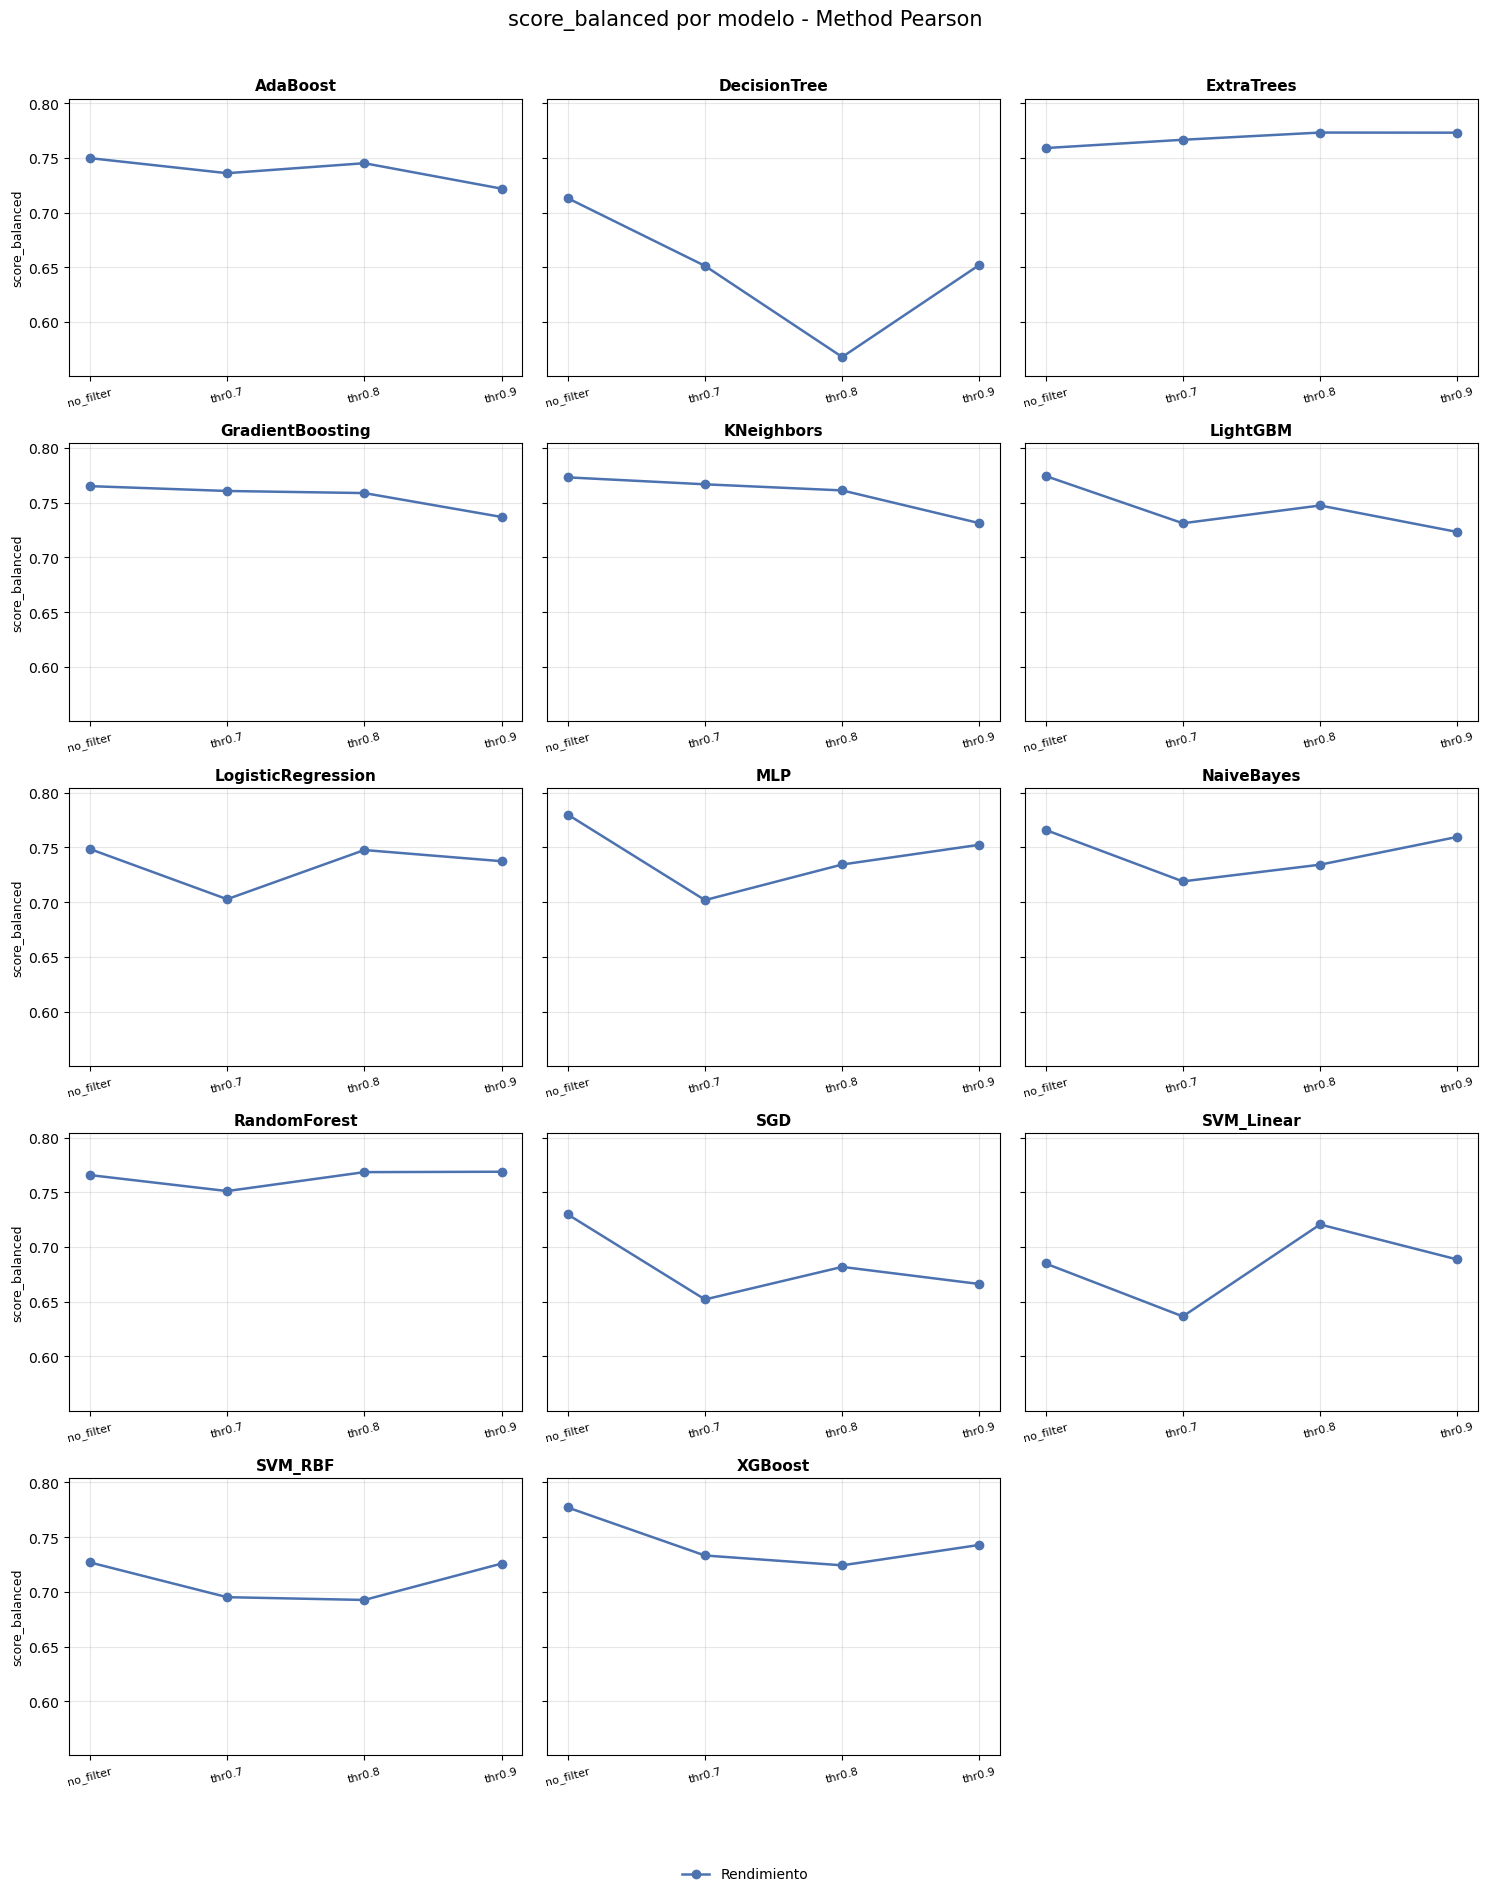

figuras/mordred/paso7b_rendimiento_vs_threshold_pearson_mordred.png guardado.


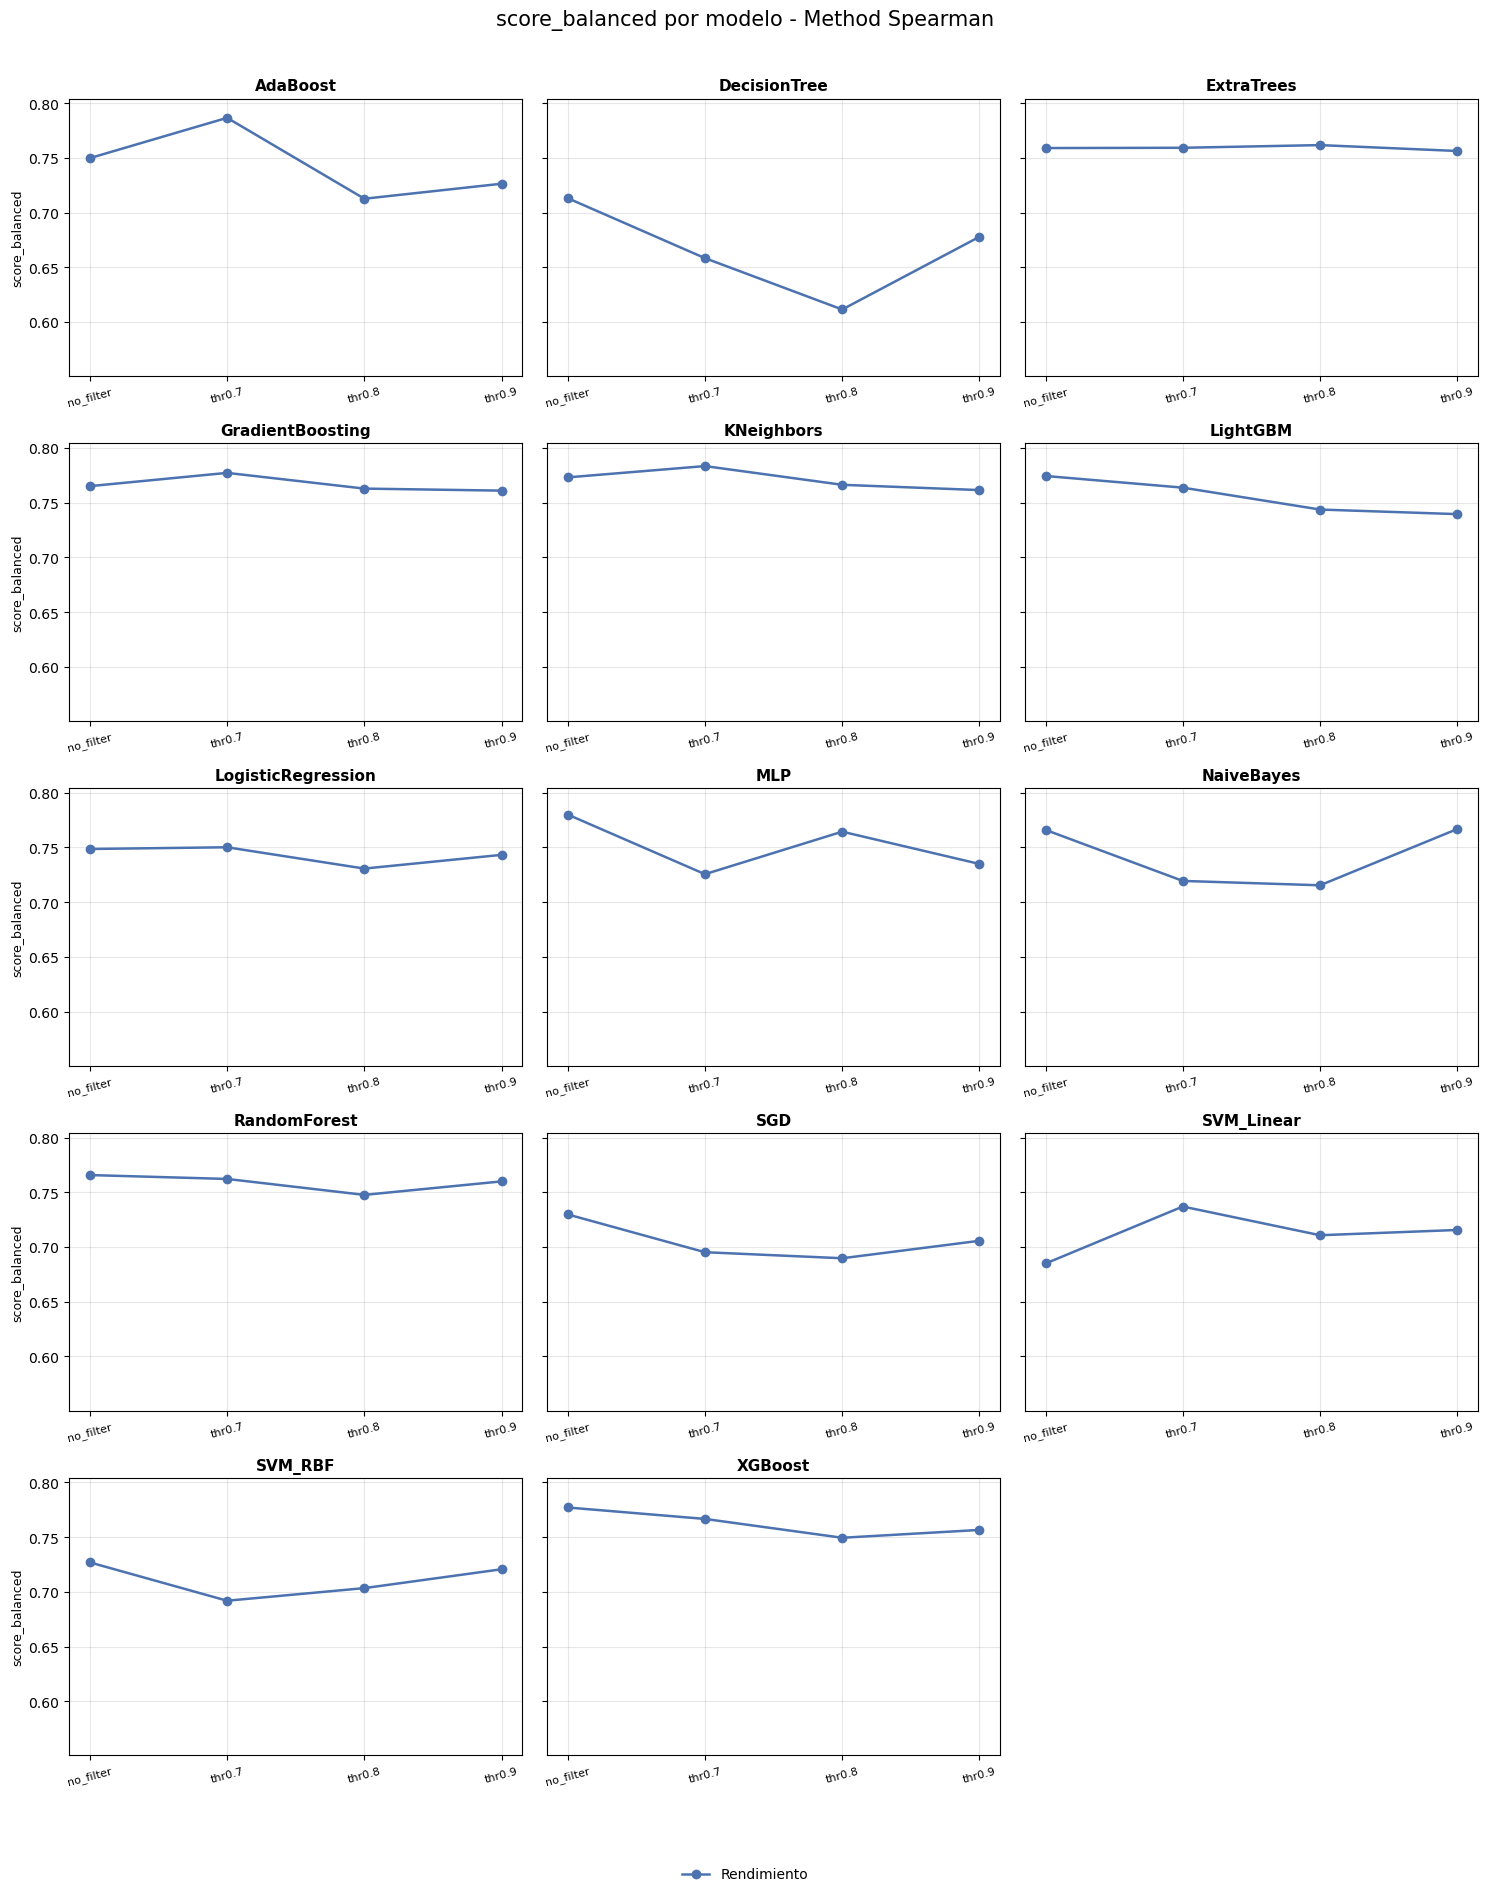

figuras/mordred/paso7b_rendimiento_vs_threshold_spearman_mordred.png guardado.


In [29]:
METRIC_TO_PLOT = "score_balanced"   # alternativas: "roc_auc_test", "cv_roc_auc_mean", "mcc_test", "f1_test"

fs_x_order   = ["no_filter", "thr0.7", "thr0.8", "thr0.9"]
pearson_map  = {"no_filter": "no_filter", "thr0.7": "pearson_thr0.7",
                "thr0.8": "pearson_thr0.8", "thr0.9": "pearson_thr0.9"}
spearman_map = {"no_filter": "no_filter", "thr0.7": "spearman_thr0.7",
                 "thr0.8": "spearman_thr0.8", "thr0.9": "spearman_thr0.9"}
models_sorted = sorted(df_results["model"].unique())

# ── Rango global del eje Y (comun a TODOS los subplots de ambas figuras) ────
all_fs_names = list(pearson_map.values()) + list(spearman_map.values())
metric_vals_global = df_results.loc[df_results["feature_set"].isin(all_fs_names), METRIC_TO_PLOT]
y_min, y_max = metric_vals_global.min(), metric_vals_global.max()
y_pad = (y_max - y_min) * 0.08 if y_max > y_min else 0.05
Y_LIM = (y_min - y_pad, y_max + y_pad)
def plot_lineplot_by_method(method_name, fmap):
    cols = 3
    rows = math.ceil(len(models_sorted) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3.5 + 0.8), sharex=False, sharey=True)
    axes = np.array(axes).reshape(-1)
    for i, model_name in enumerate(models_sorted):
        ax = axes[i]
        sub = df_results[df_results["model"] == model_name]
        y_vals = []
        for x_label in fs_x_order:
            fs_real = fmap[x_label]
            val = sub.loc[sub["feature_set"] == fs_real, METRIC_TO_PLOT]
            y_vals.append(val.values[0] if len(val) > 0 else np.nan)
        ax.plot(fs_x_order, y_vals, marker="o", color="#4C72B0",
                linewidth=1.8, markersize=6, label="Rendimiento")
        ax.set_title(model_name, fontsize=11, fontweight="bold")
        ax.set_ylim(Y_LIM)
        ax.grid(alpha=0.3)
        ax.tick_params(axis="x", rotation=15, labelsize=8)
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
    for r in range(rows):
        axes[r * cols].set_ylabel(METRIC_TO_PLOT, fontsize=9)
    # ── Leyenda unica, debajo de toda la figura ──────────────────────────────
    legend_handles = [
        plt.Line2D([0], [0], color="#4C72B0", marker="o", linewidth=1.8, label="Rendimiento"),
    ]
    fig.legend(handles=legend_handles, loc="lower center", ncol=2,
               fontsize=10, bbox_to_anchor=(0.5, -0.02), frameon=False)
    plt.suptitle(f"{METRIC_TO_PLOT} por modelo - Method {method_name}", fontsize=15, y=1.01)
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    out_lineplot = f'{FIGURAS}/paso7b_rendimiento_vs_threshold_{method_name.lower()}_mordred.png'
    plt.savefig(out_lineplot, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"{out_lineplot} guardado.")
plot_lineplot_by_method("Pearson", pearson_map)
plot_lineplot_by_method("Spearman", spearman_map)

## 3.2 Realización de las matrices de confusión

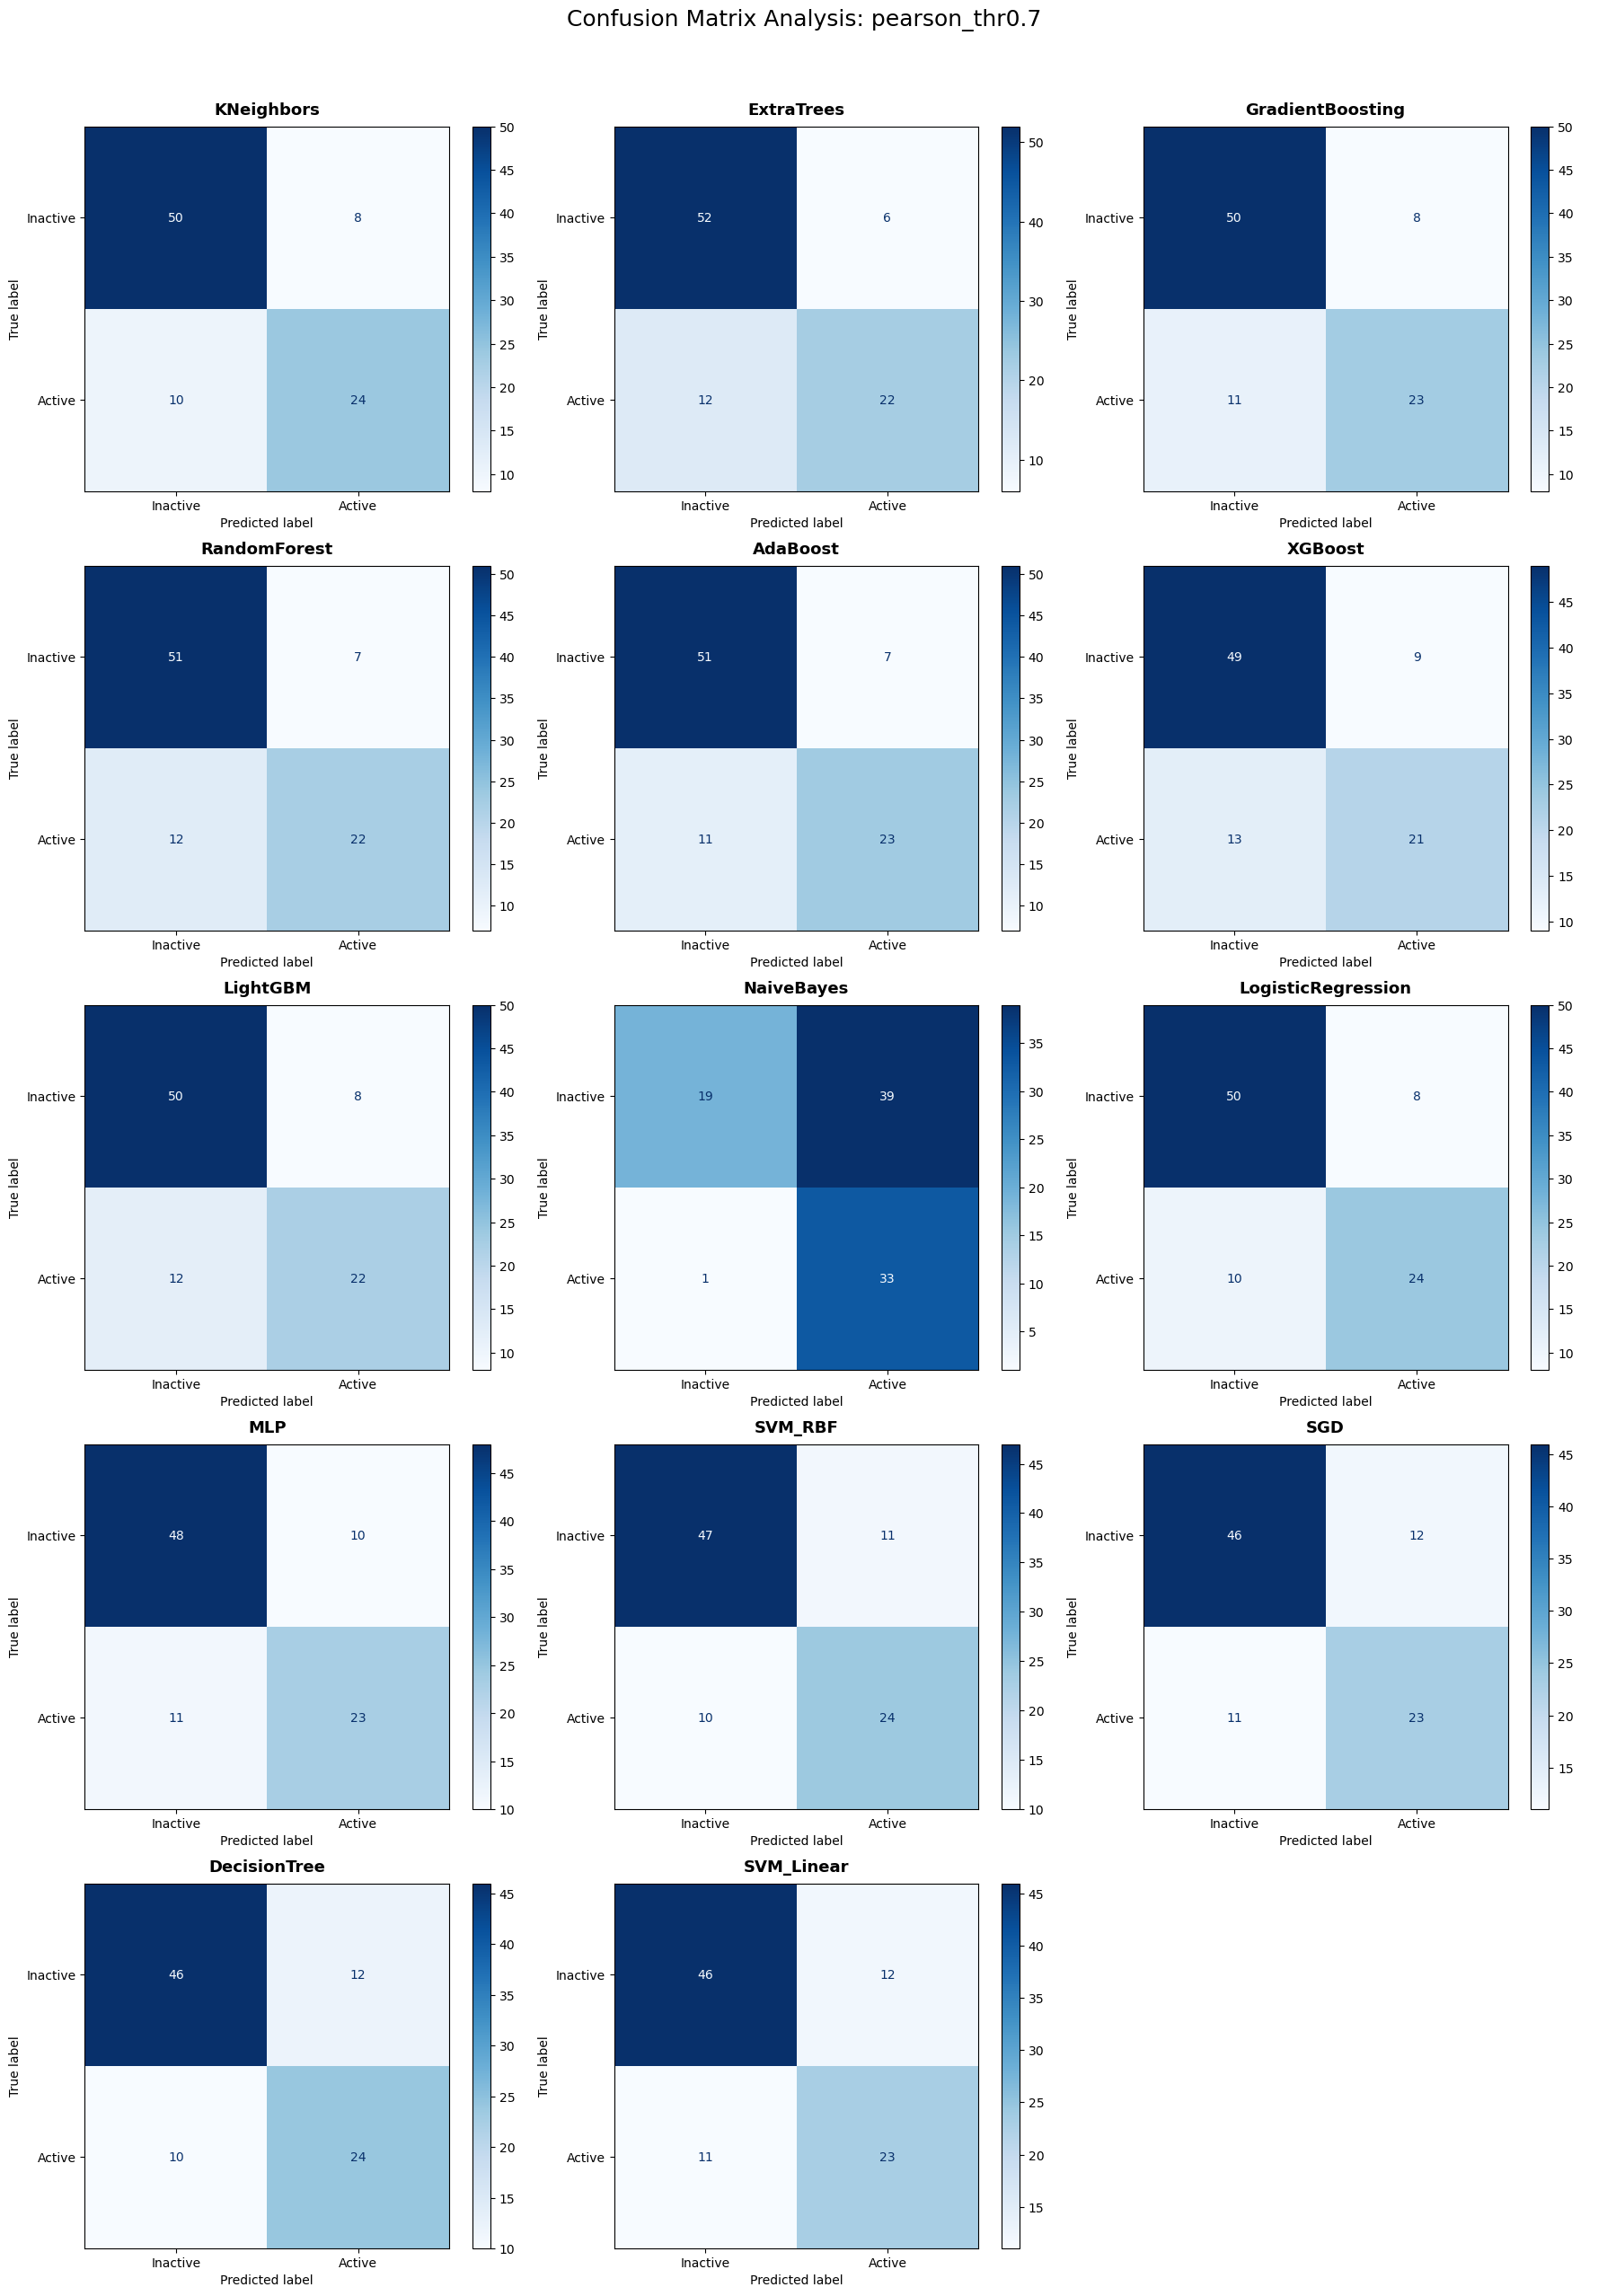

figuras/mordred/paso7_confusion_pearson_thr0.7_mordred.png guardado.


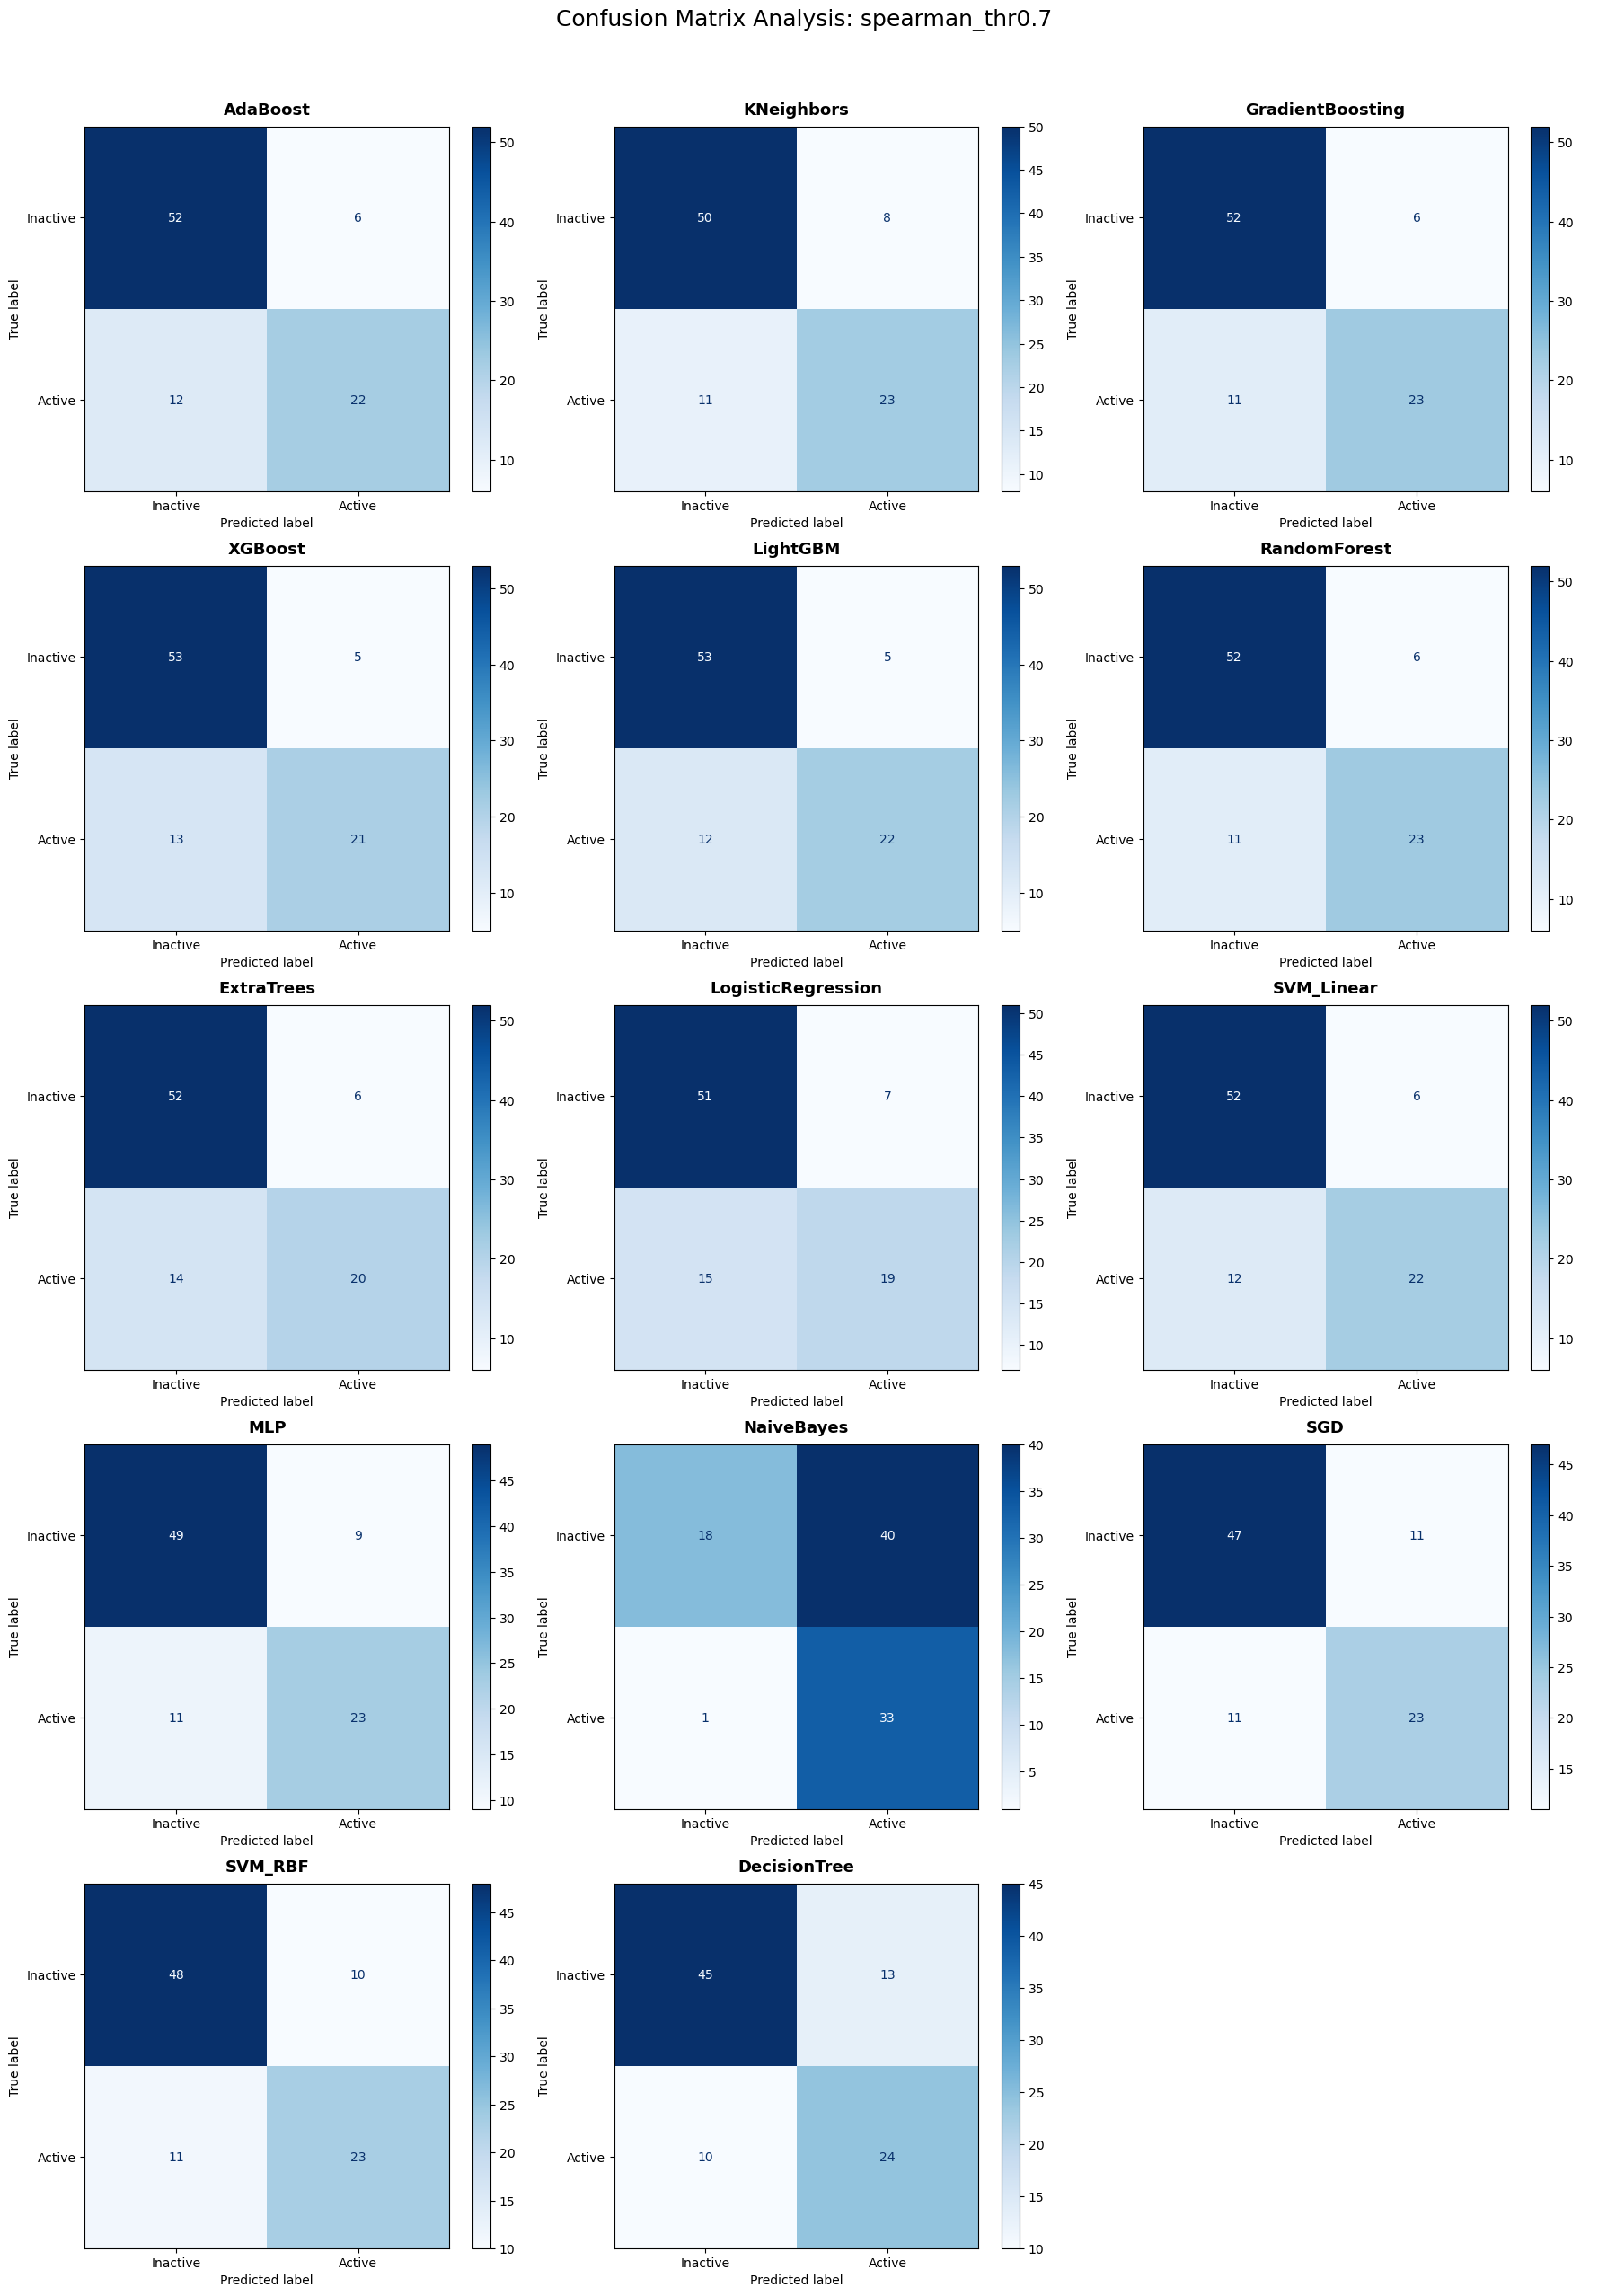

figuras/mordred/paso7_confusion_spearman_thr0.7_mordred.png guardado.


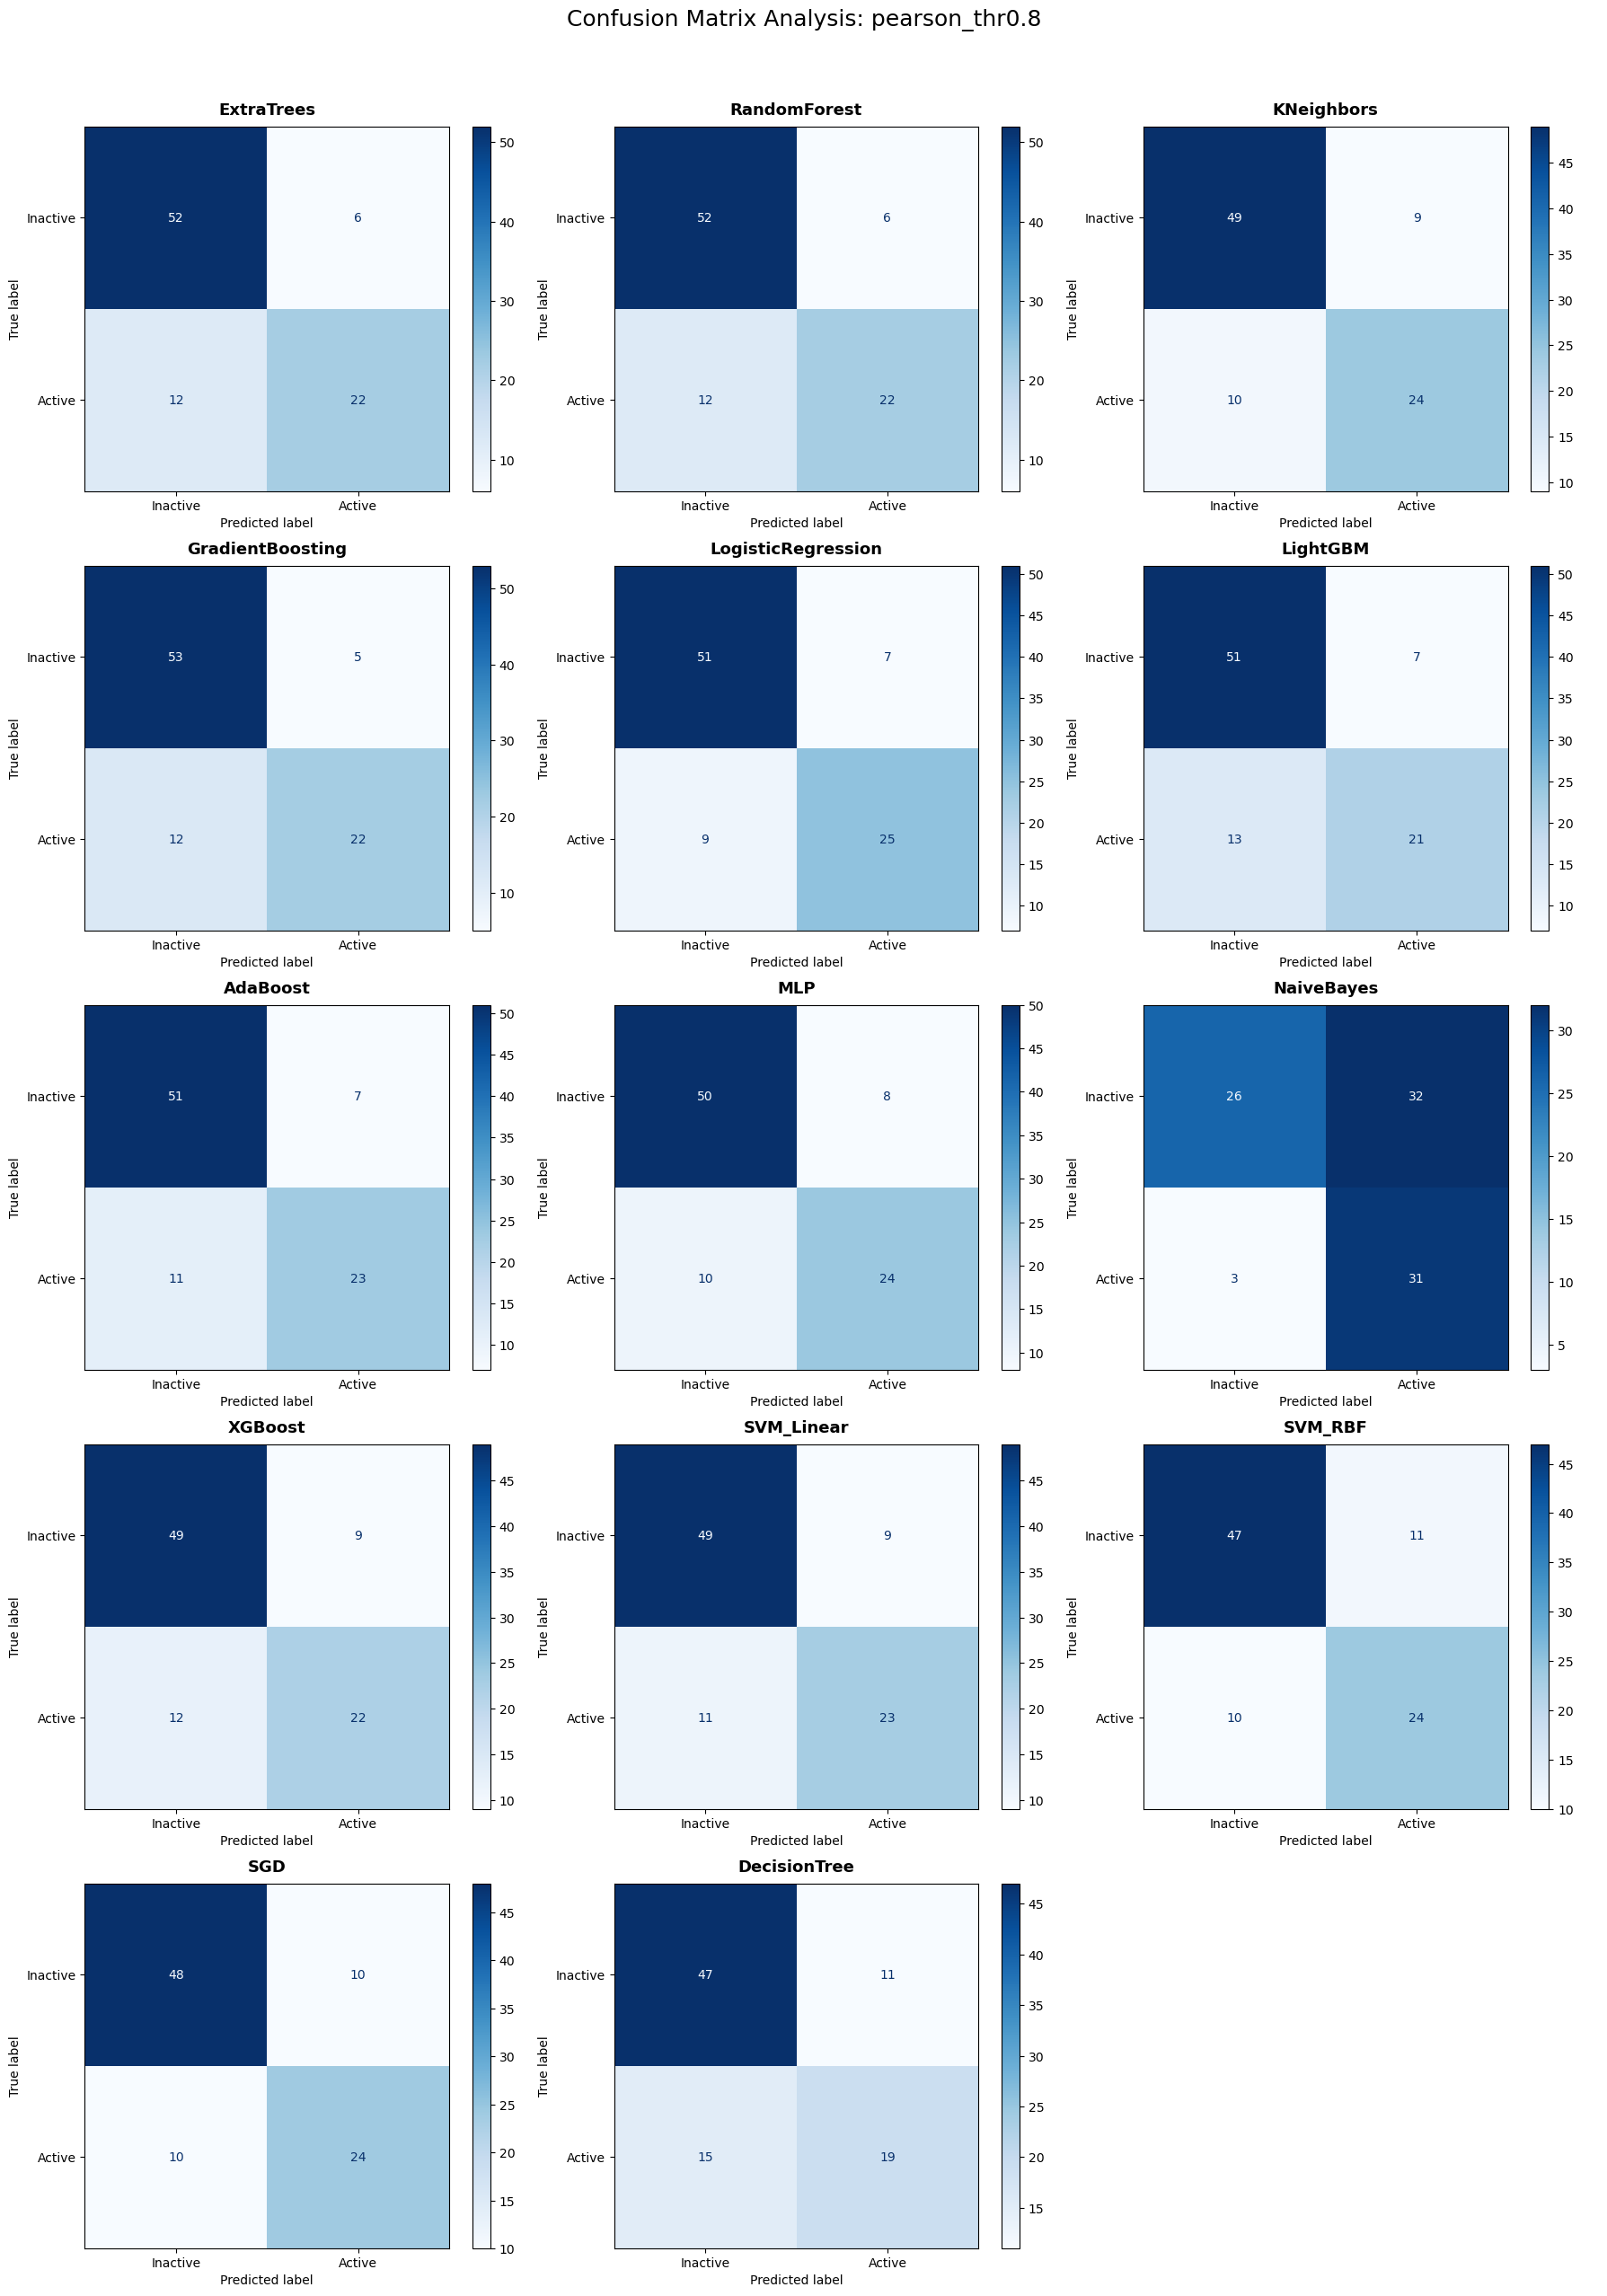

figuras/mordred/paso7_confusion_pearson_thr0.8_mordred.png guardado.


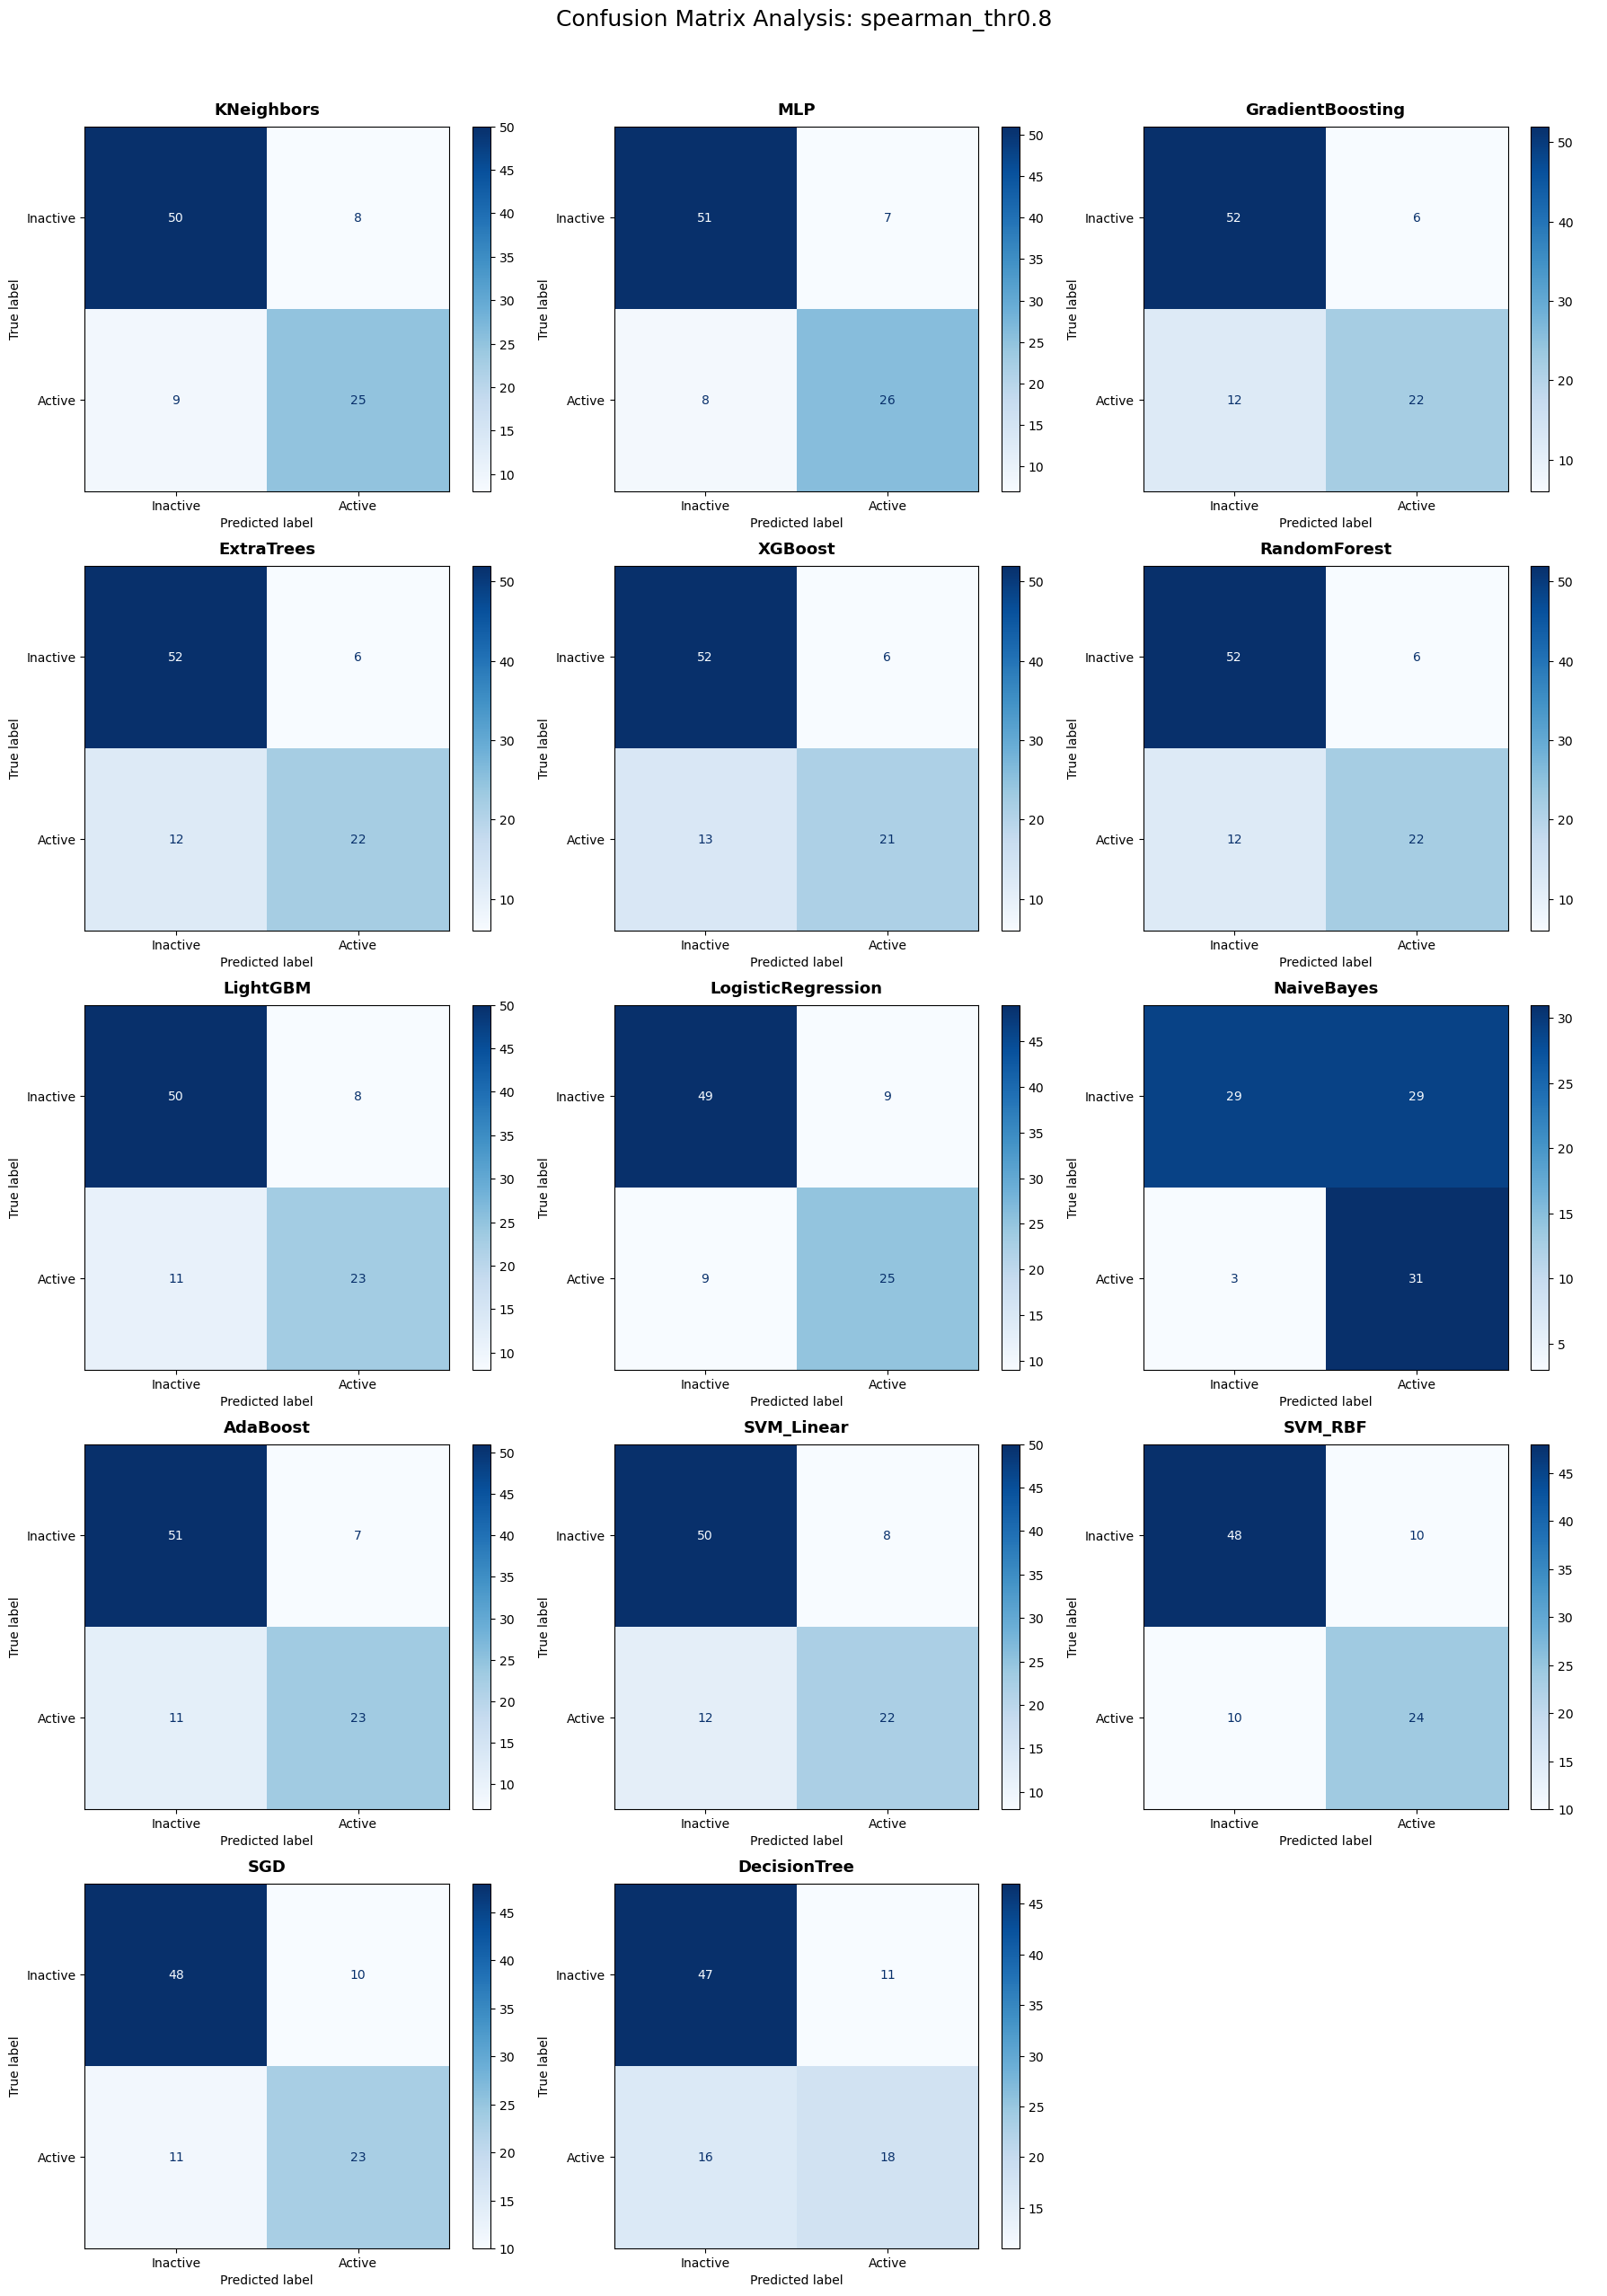

figuras/mordred/paso7_confusion_spearman_thr0.8_mordred.png guardado.


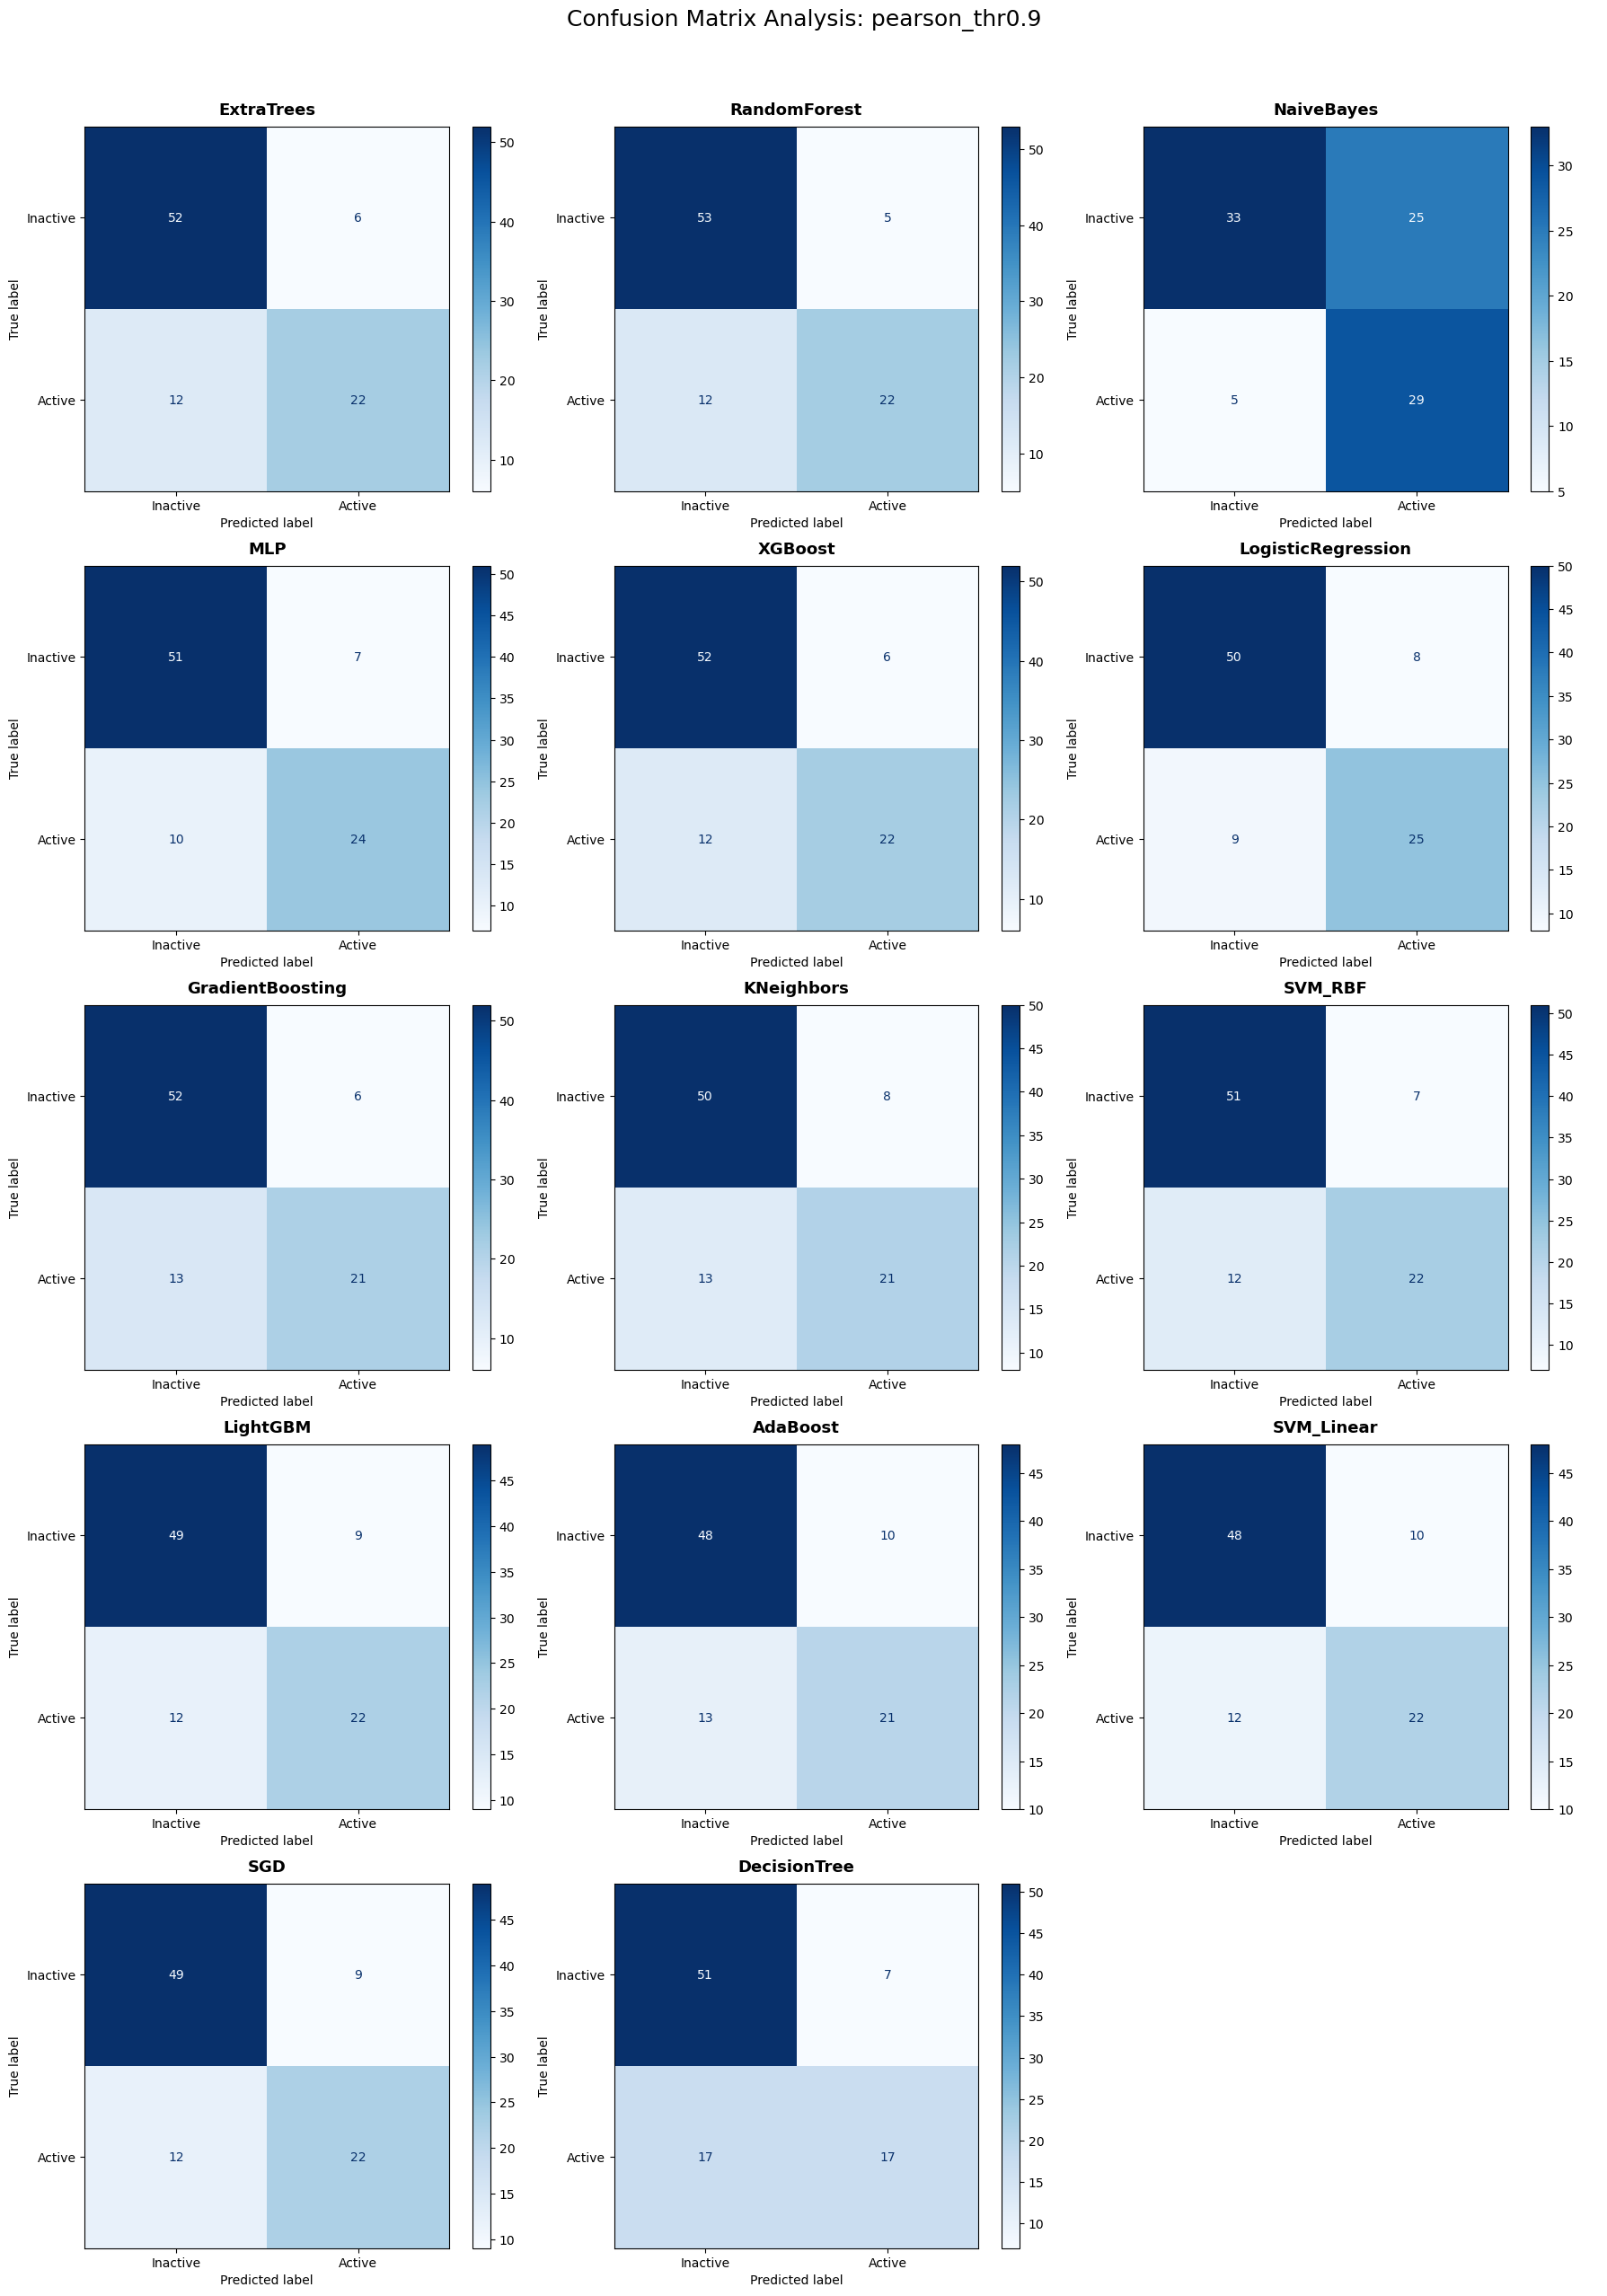

figuras/mordred/paso7_confusion_pearson_thr0.9_mordred.png guardado.


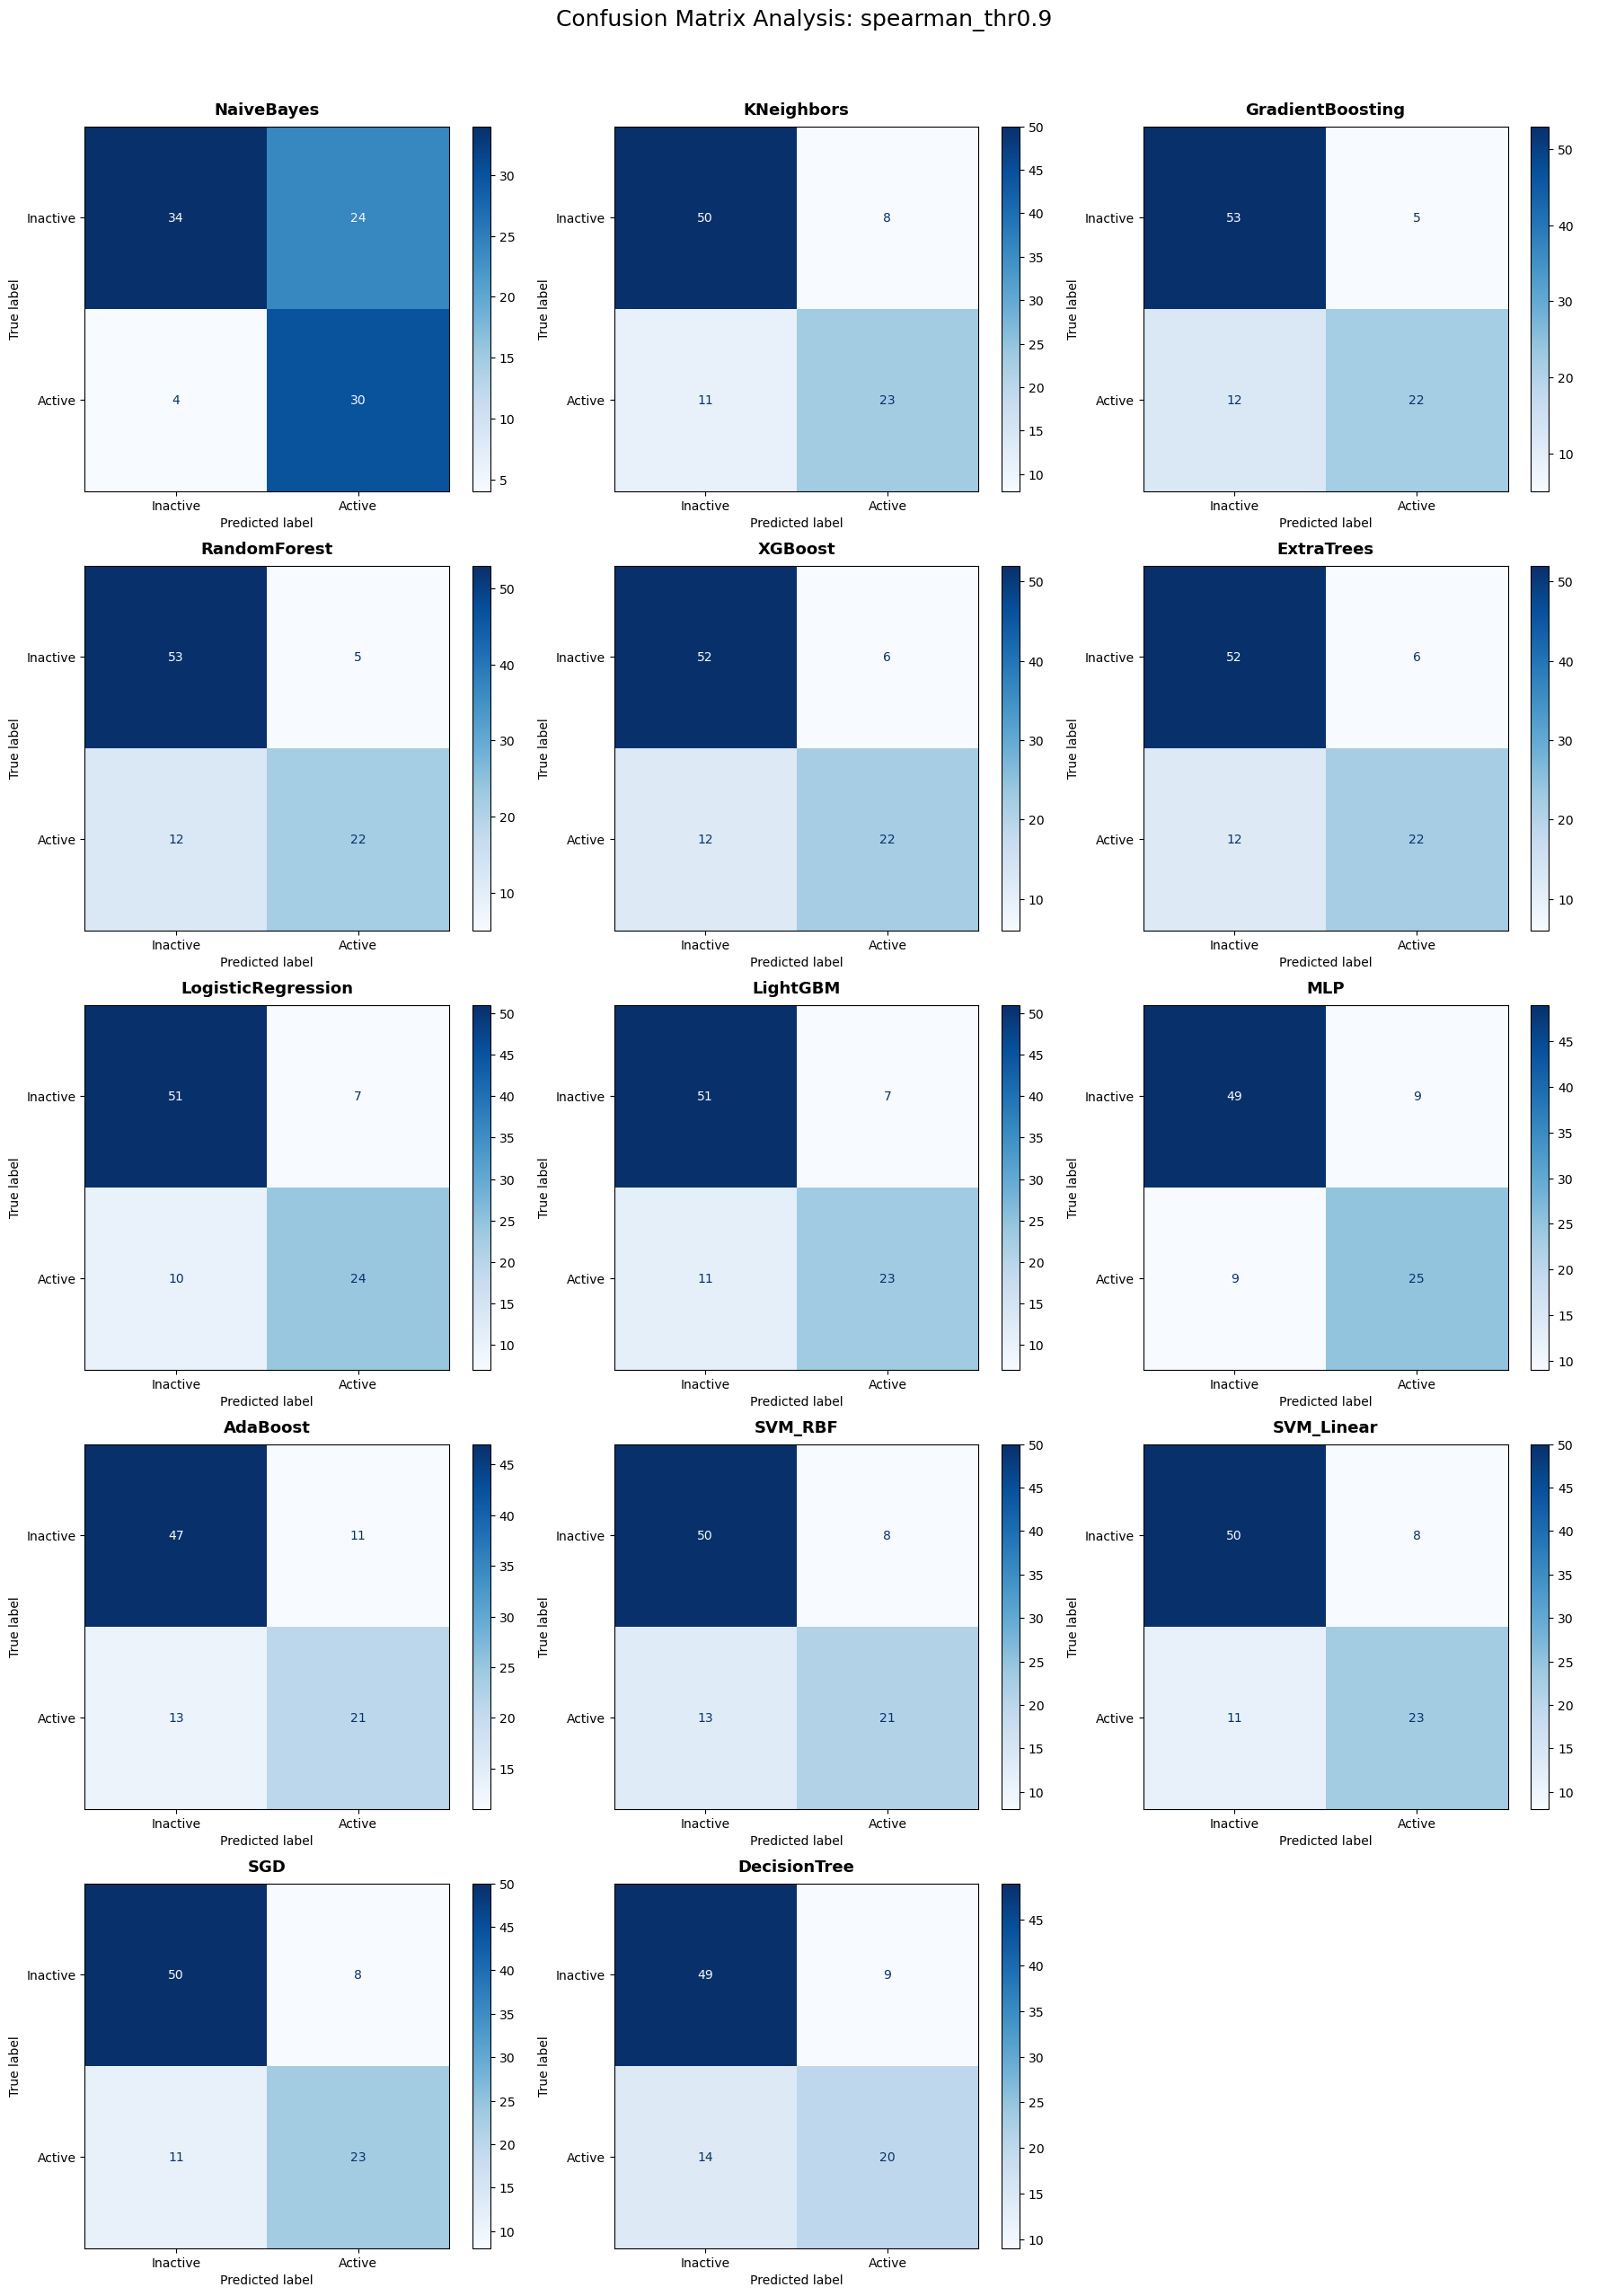

figuras/mordred/paso7_confusion_spearman_thr0.9_mordred.png guardado.


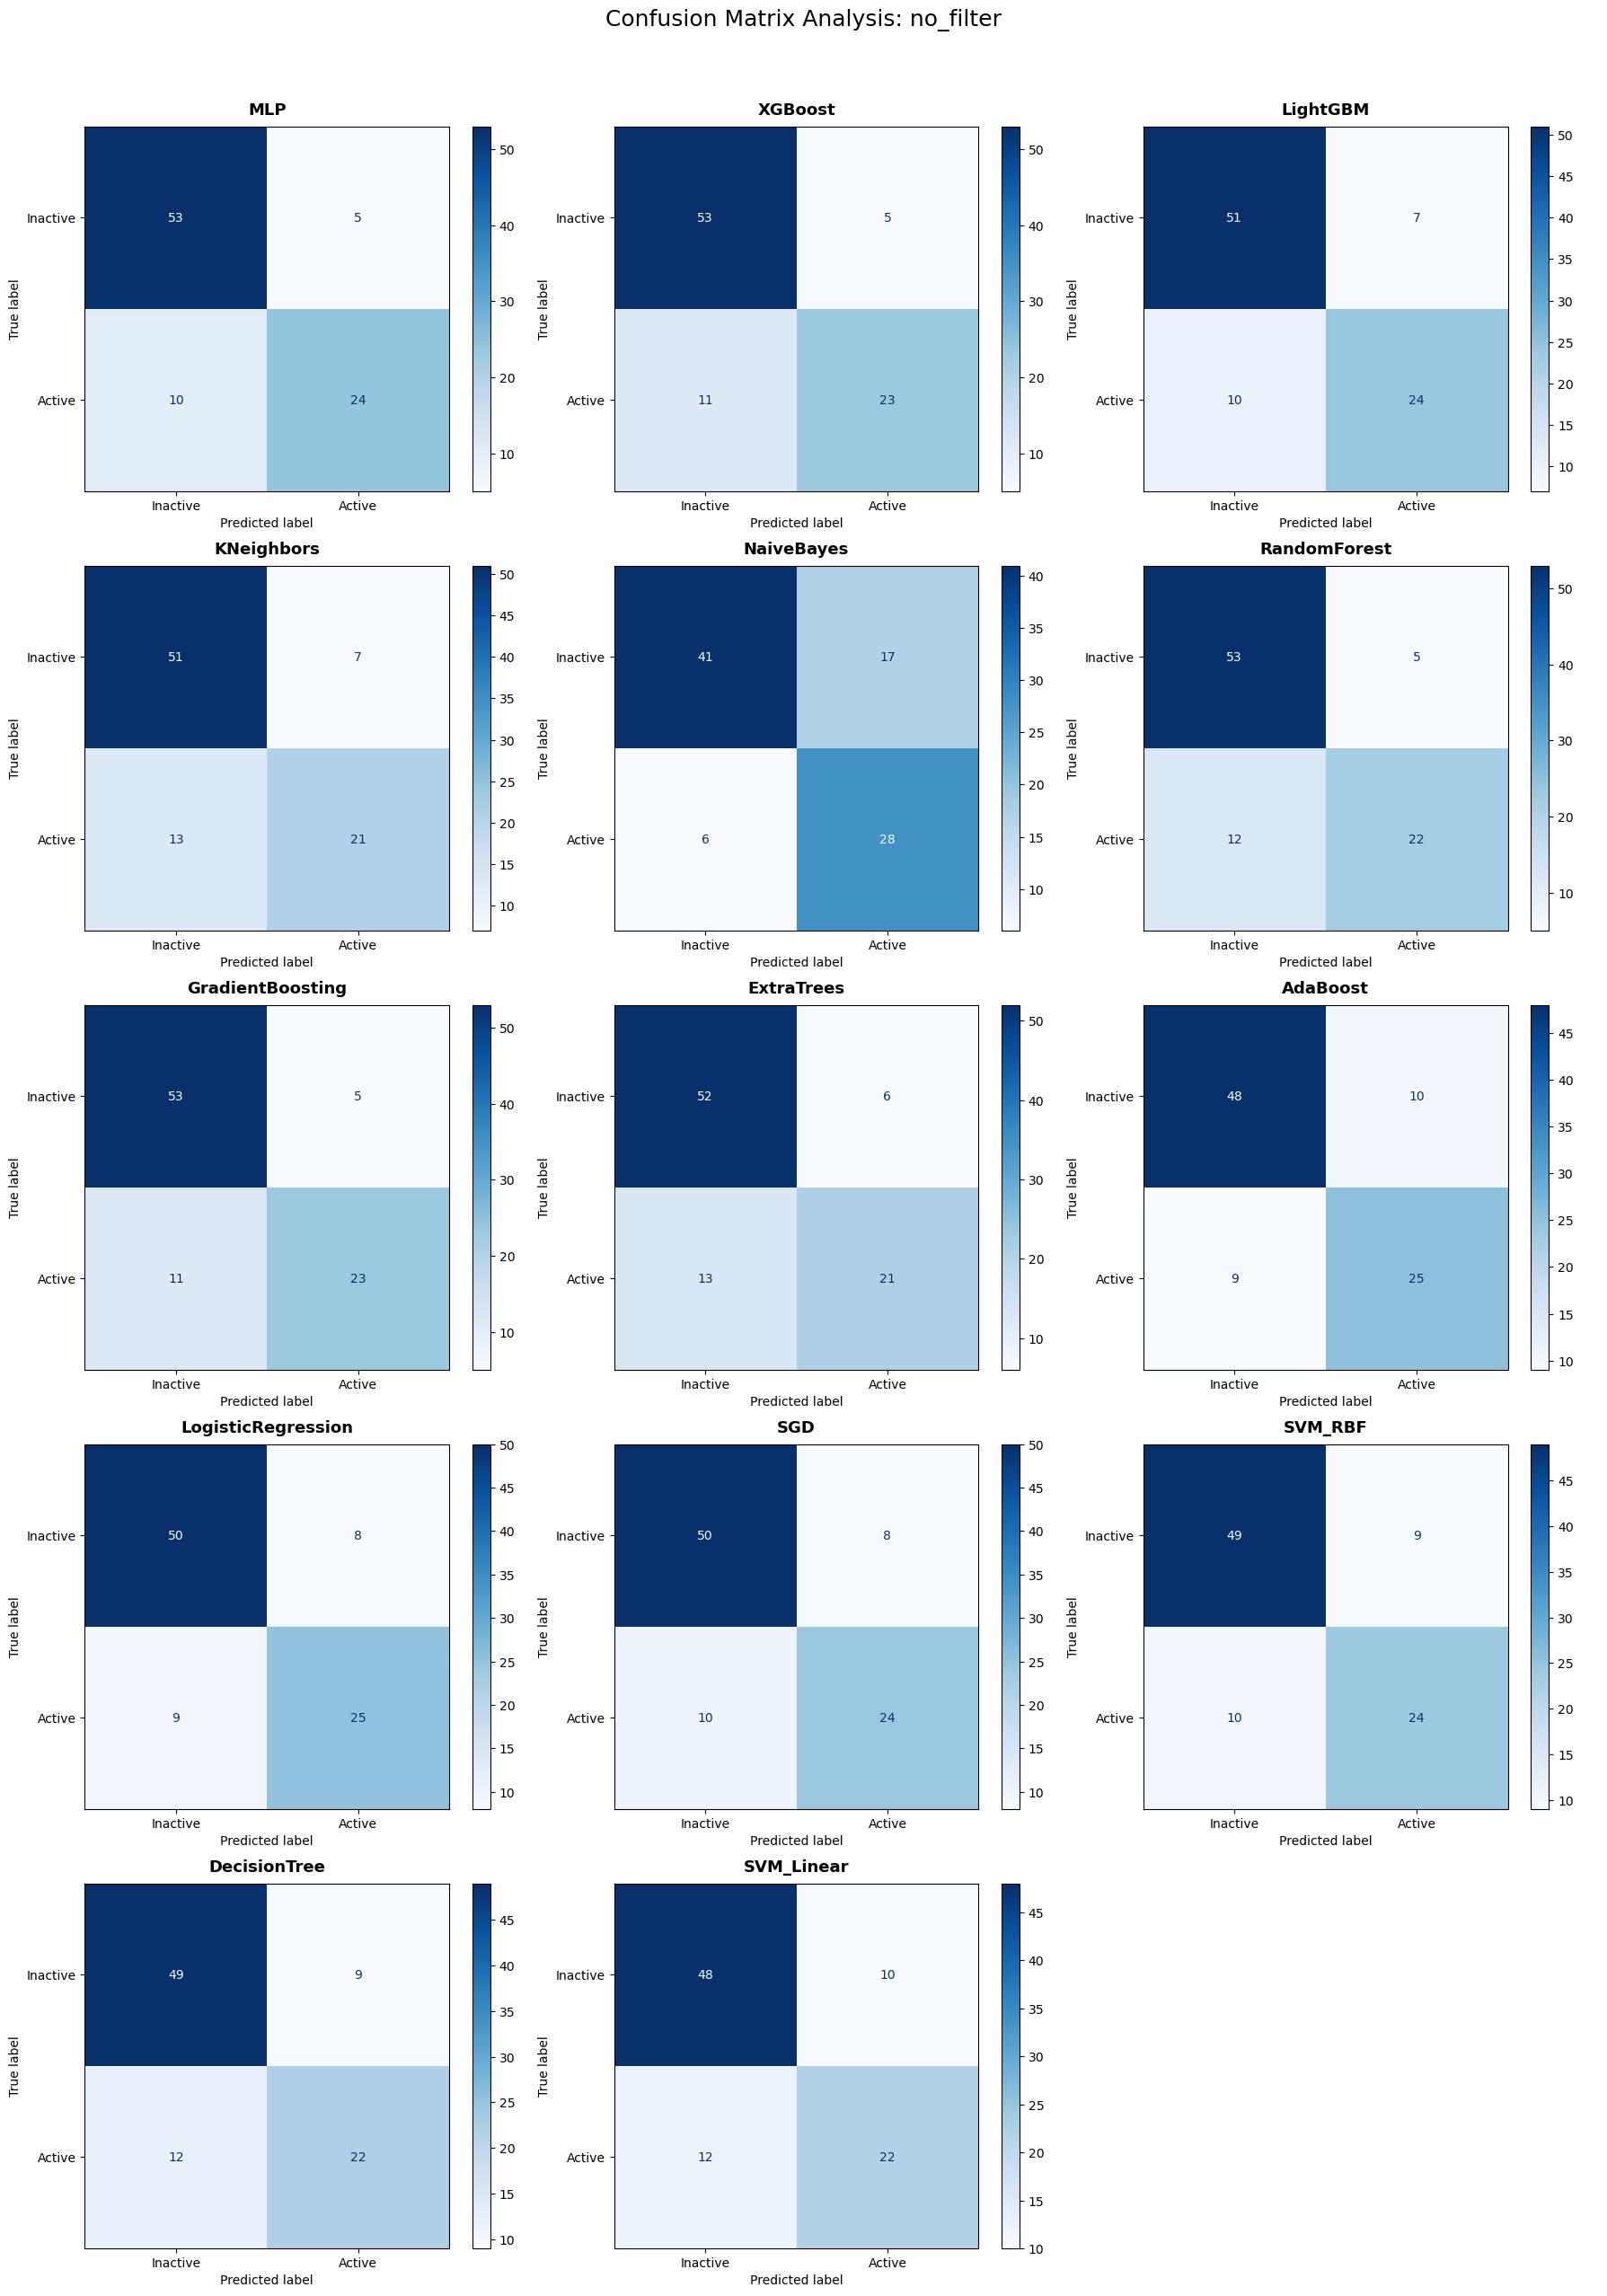

figuras/mordred/paso7_confusion_no_filter_mordred.png guardado.


In [30]:
def plot_matrices_by_feature_set(fs_name, results_df, estimators_dict, feature_sets_dict):
    fs_results = results_df[results_df["feature_set"] == fs_name]
    n_models = len(fs_results)
    if n_models == 0:
        return
    cols = 3
    rows = math.ceil(n_models / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
    axes = np.array(axes).reshape(-1)
    for i, (_, row) in enumerate(fs_results.iterrows()):
        model_name = row['model']
        key = f"{model_name}__{fs_name}"
        est = estimators_dict[key]
        fs_cols_local = feature_sets_dict[fs_name]
        y_pred = est.predict(X_test_full[fs_cols_local])
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(cm, display_labels=["Inactive", "Active"])
        disp.plot(ax=axes[i], colorbar=True, cmap="Blues")
        axes[i].set_title(f"{model_name}", fontsize=13, pad=10, fontweight='bold')
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    plt.suptitle(f"Confusion Matrix Analysis: {fs_name}", fontsize=18, y=1.02)
    plt.tight_layout()
    plt.savefig(f'{FIGURAS}/paso7_confusion_{fs_name}_mordred.png', dpi=150, bbox_inches="tight")
    plt.show()
    print(f"{FIGURAS}/paso7_confusion_{fs_name}_mordred.png guardado.")

# Una figura por cada uno de los 7 feature sets (pearson/spearman x 0.7/0.8/0.9, + no_filter)
for fs_name in feature_sets.keys():
    plot_matrices_by_feature_set(fs_name, df_results, best_estimators, feature_sets)


## 3.3 Realización de las curvas ROC

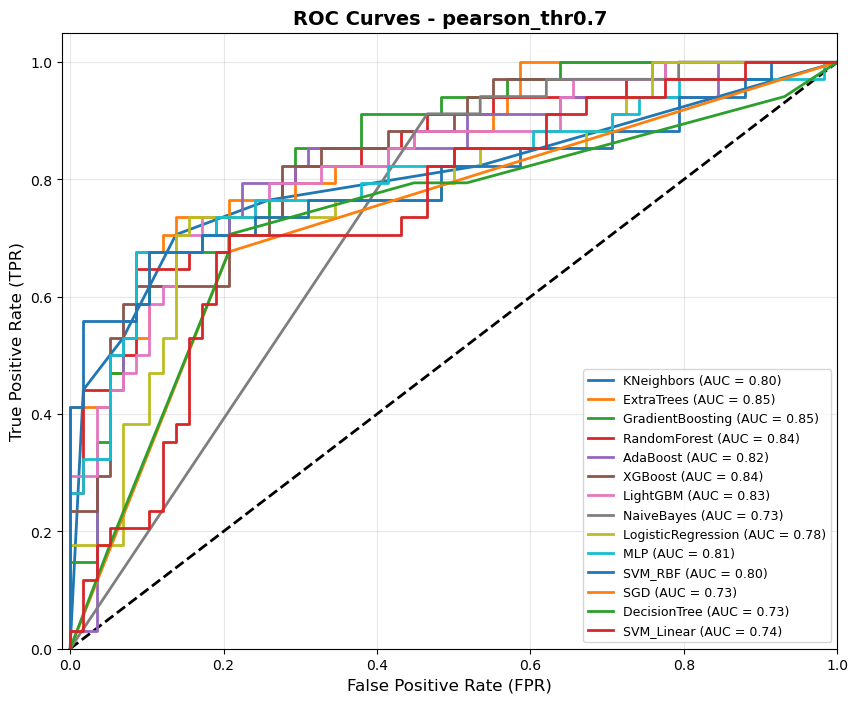

figuras/mordred/paso7_roc_comparison_pearson_thr0.7_mordred.png guardado.


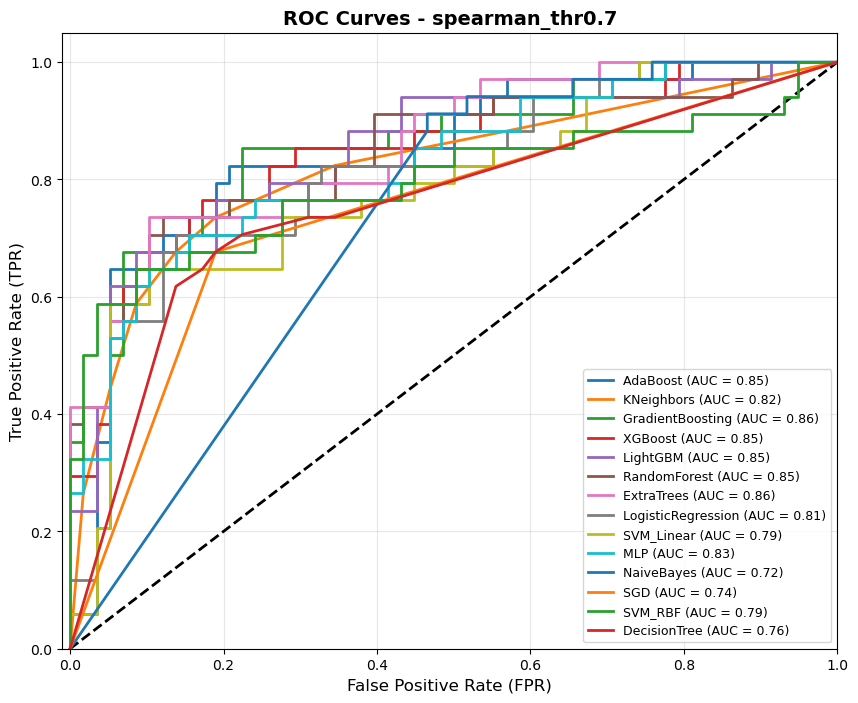

figuras/mordred/paso7_roc_comparison_spearman_thr0.7_mordred.png guardado.


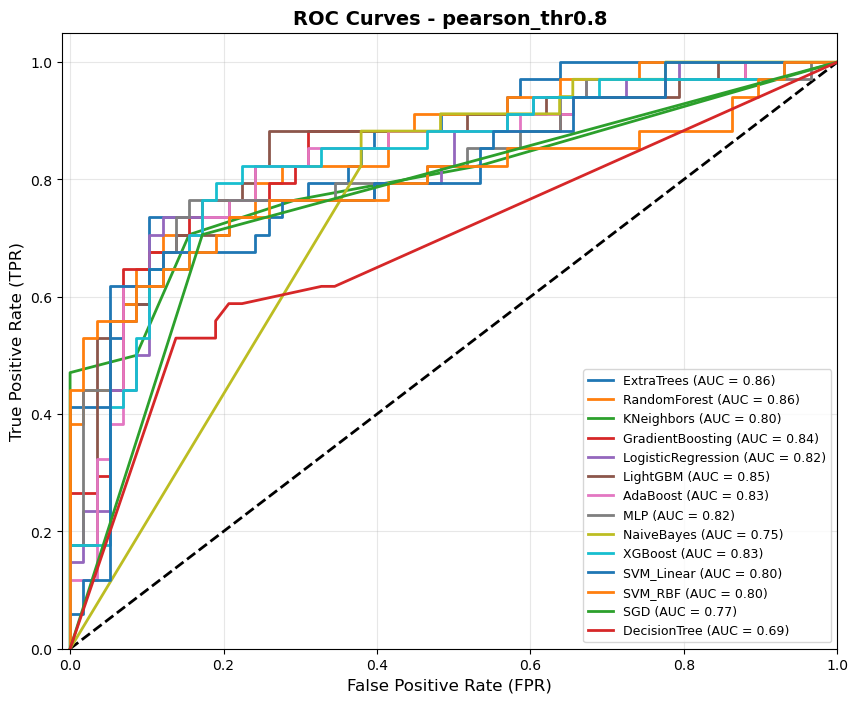

figuras/mordred/paso7_roc_comparison_pearson_thr0.8_mordred.png guardado.


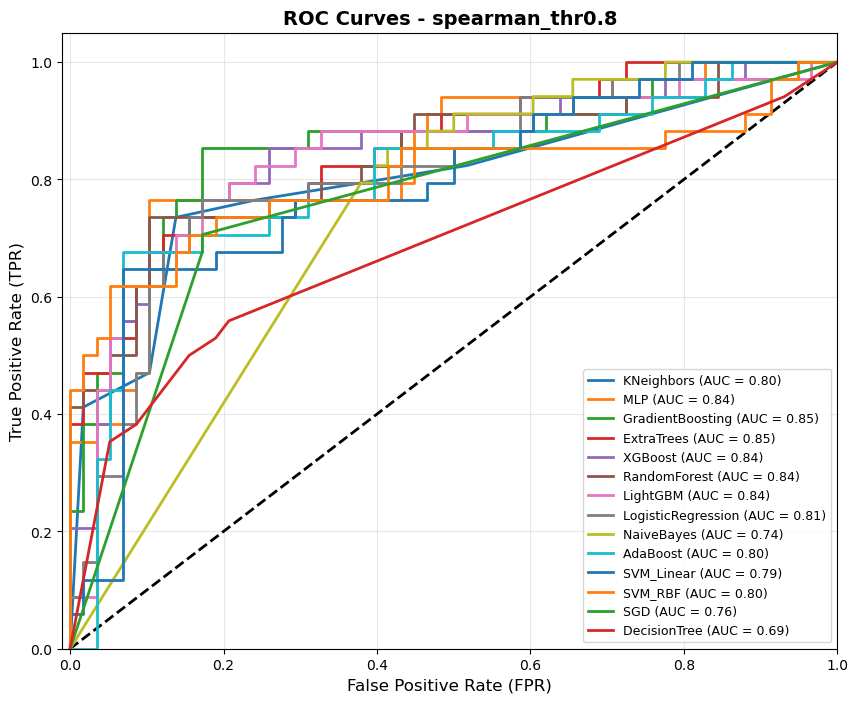

figuras/mordred/paso7_roc_comparison_spearman_thr0.8_mordred.png guardado.


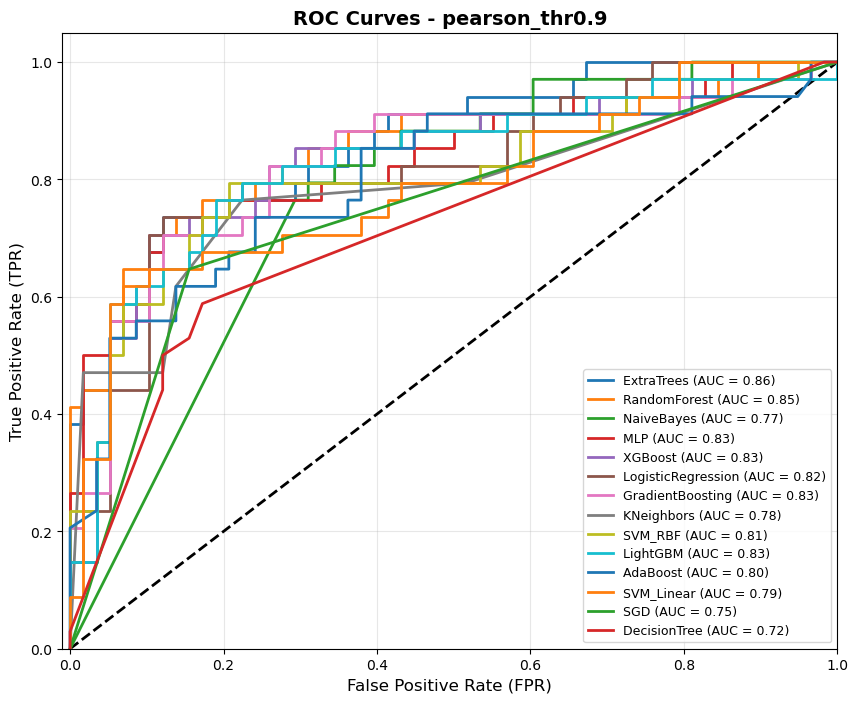

figuras/mordred/paso7_roc_comparison_pearson_thr0.9_mordred.png guardado.


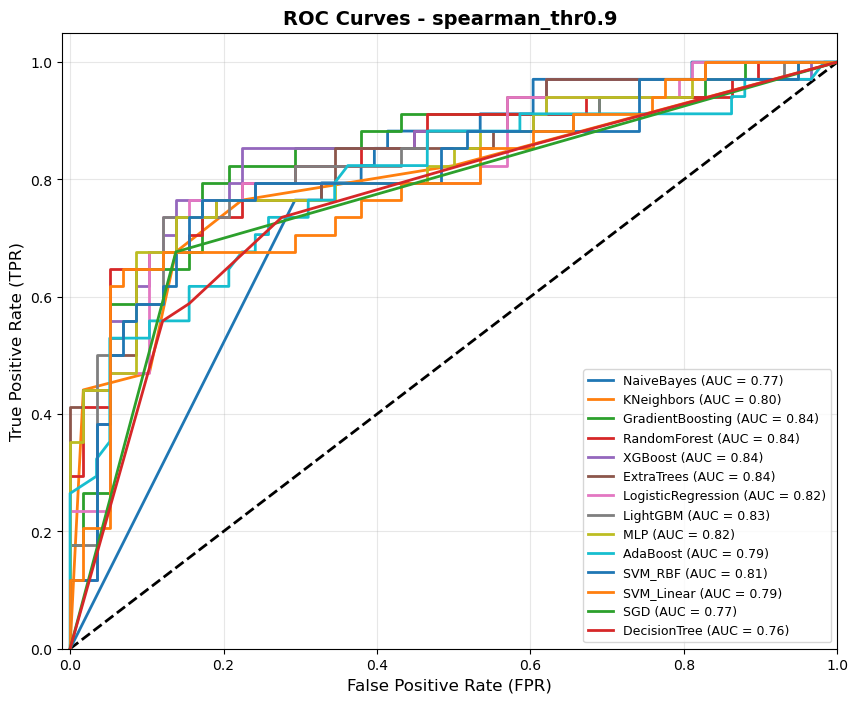

figuras/mordred/paso7_roc_comparison_spearman_thr0.9_mordred.png guardado.


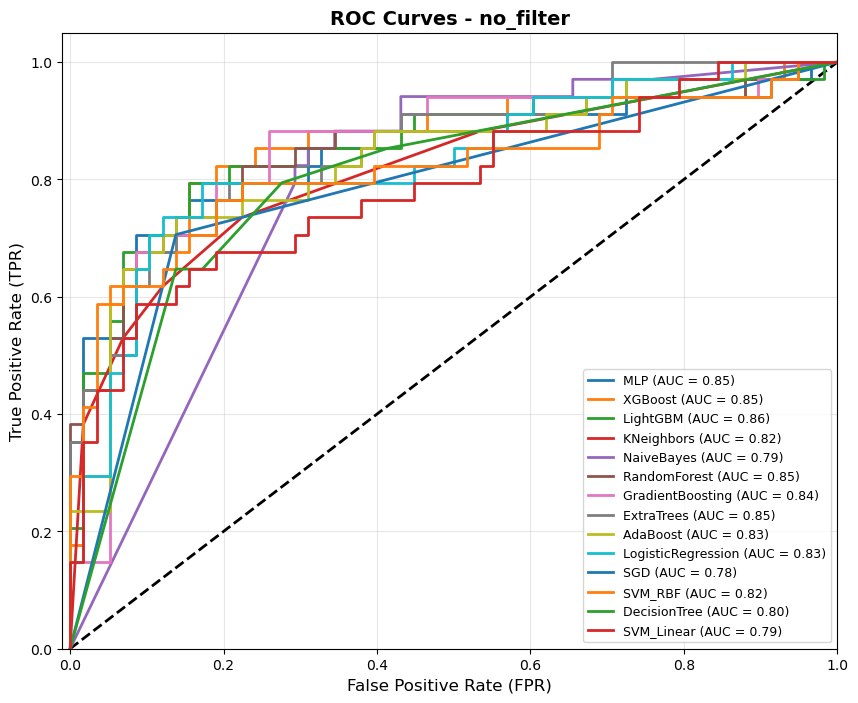

figuras/mordred/paso7_roc_comparison_no_filter_mordred.png guardado.


In [31]:
def plot_roc_curves_by_feature_set(fs_name, results_df, estimators_dict, feature_sets_dict):
    fs_results = results_df[results_df["feature_set"] == fs_name]
    if len(fs_results) == 0:
        return
    plt.figure(figsize=(10, 8))
    plt.plot([0, 1], [0, 1], 'k--', lw=2)

    for _, row in fs_results.iterrows():
        model_name = row['model']
        key = f"{model_name}__{fs_name}"
        est = estimators_dict[key]
        fs_cols_local = feature_sets_dict[fs_name]
        if hasattr(est, "predict_proba"):
            y_score = est.predict_proba(X_test_full[fs_cols_local])[:, 1]
        else:
            y_score = est.decision_function(X_test_full[fs_cols_local])
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.2f})')

    plt.xlim([-0.01, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)', fontsize=12)
    plt.ylabel('True Positive Rate (TPR)', fontsize=12)
    plt.title(f'ROC Curves - {fs_name}', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=9)
    plt.grid(alpha=0.3)
    plt.savefig(f'{FIGURAS}/paso7_roc_comparison_{fs_name}_mordred.png', dpi=150, bbox_inches="tight")
    plt.show()
    print(f"{FIGURAS}/paso7_roc_comparison_{fs_name}_mordred.png guardado.")

# Una figura por cada uno de los 7 feature sets
for fs_name in feature_sets.keys():
    plot_roc_curves_by_feature_set(fs_name, df_results, best_estimators, feature_sets)


## 3.4 Realización del overfit gap

In [32]:
pivot_gap = df_results.pivot_table(
    index="model", columns="feature_set",
    values="overfit_gap", aggfunc="min"
)
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(pivot_gap, annot=True, fmt=".2f", cmap="RdYlGn_r",
            center=0, ax=ax, linewidths=0.5)
ax.set_title("Overfit Gap (acc_train − acc_test)")
plt.tight_layout()
plt.savefig(f'{FIGURAS}/paso7_overfit_heatmap_mordred.png',
            dpi=150, bbox_inches="tight")
plt.close()

## 3.5 Ranking de los modelos

In [33]:
best_est = best_estimators[best_key]
best_fs  = feature_sets[best_row["feature_set"]]
y_pred   = best_est.predict(X_test_full[best_fs])
 
print(f"\n{'='*60}")
print(f"MEJOR MODELO : {best_row['model']}")
print(f"Feature set  : {best_row['feature_set']} ({int(best_row['n_features'])} descriptores)")
print(f"{'='*60}")
print(classification_report(y_test, y_pred, target_names=["Inactivo", "Activo"]))
print(f"MCC = {matthews_corrcoef(y_test, y_pred):.4f}")
try:
    y_prob = best_est.predict_proba(X_test_full[best_fs])[:, 1]
    print(f"ROC-AUC = {roc_auc_score(y_test, y_prob):.4f}")
except AttributeError:
    pass
 
pd.DataFrame(
    classification_report(y_test, y_pred,
                           target_names=["Inactivo", "Activo"],
                           output_dict=True)
).T.to_csv(f'{OUTPUT_DIR_ML}/paso7_report_mejor_modelo.csv')
 
print(f"\n✅ Gráficos y reportes del paso 7 guardados.")


MEJOR MODELO : AdaBoost
Feature set  : spearman_thr0.7 (154 descriptores)
              precision    recall  f1-score   support

    Inactivo       0.81      0.90      0.85        58
      Activo       0.79      0.65      0.71        34

    accuracy                           0.80        92
   macro avg       0.80      0.77      0.78        92
weighted avg       0.80      0.80      0.80        92

MCC = 0.5703
ROC-AUC = 0.8474

✅ Gráficos y reportes del paso 7 guardados.


# 4. Dominio de aplicabilidad - kNN 

TOP 3 MODELOS SELECCIONADOS PARA EL DOMINIO DE APLICABILIDAD (por CV)
     model     feature_set  n_features  cv_roc_auc_mean  roc_auc_test
  AdaBoost spearman_thr0.7         154         0.836947      0.847363
KNeighbors spearman_thr0.7         154         0.854364      0.819219
       MLP       no_filter        1207         0.868484      0.848377

Descriptores (k)         : 154
Compuestos train (n)     : 378
Umbral kNN-AD            : 14.9527

Train - dist. media (mean +/- std): 8.1802 +/- 3.3863
Test  - dentro del AD    : 89 (96.7%)
Test  - fuera del AD     : 3 (3.3%)


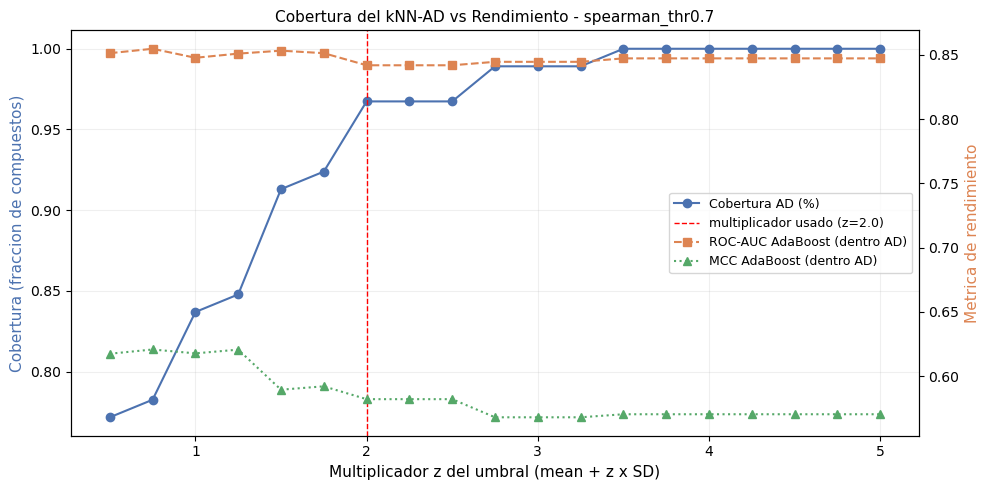

resultados dominio de aplicabilidad mordred/paso8_ad_coverage_spearman_thr0.7_mordred.png guardado.
split  in_AD
test   0          3
       1         89
train  1        378
resultados dominio de aplicabilidad mordred/paso8_knnAD_spearman_thr0.7_mordred.csv guardado.

[1/3] MODELO: AdaBoost  |  Feature set: spearman_thr0.7


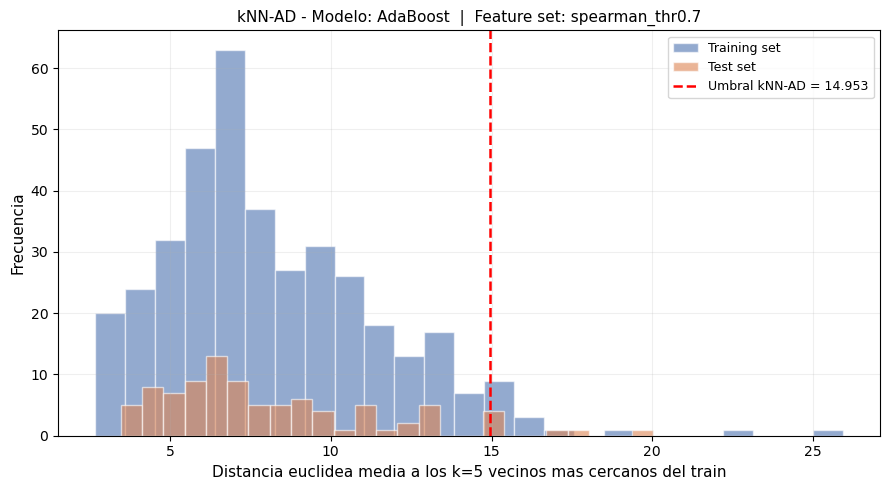

resultados dominio de aplicabilidad mordred/paso8_knnAD_hist_top1_AdaBoost_mordred.png guardado.

-- Test completo (n=92) --
  Accuracy  : 0.8043
  F1        : 0.7097
  MCC       : 0.5703
  ROC-AUC   : 0.8474

-- Test dentro del AD (n=89) --
  Accuracy  : 0.8090
  F1        : 0.7213
  MCC       : 0.5820
  ROC-AUC   : 0.8420

-- Test fuera del AD (n=3) --
  Accuracy  : 0.6667
  F1        : 0.0000
  MCC       : 0.0000
  ROC-AUC   : 1.0000
resultados dominio de aplicabilidad mordred/paso8_ad_metrics_top1_AdaBoost_mordred.csv guardado.

[2/3] MODELO: KNeighbors  |  Feature set: spearman_thr0.7


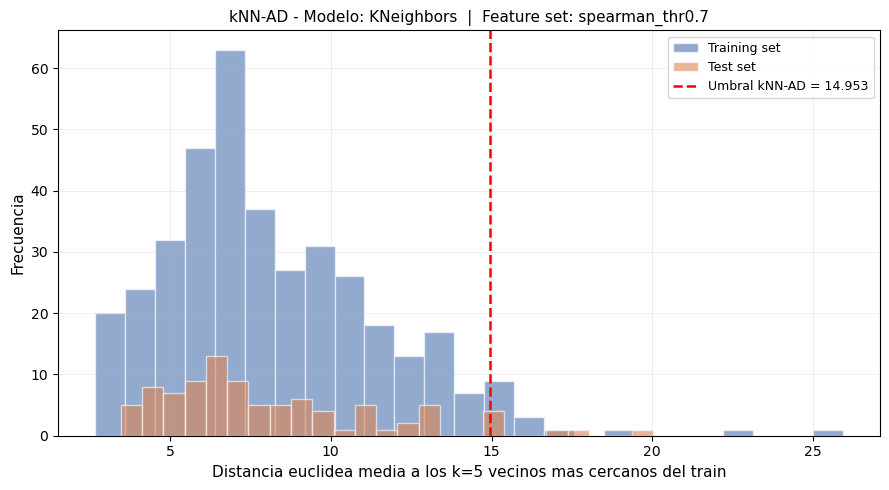

resultados dominio de aplicabilidad mordred/paso8_knnAD_hist_top2_KNeighbors_mordred.png guardado.

-- Test completo (n=92) --
  Accuracy  : 0.7935
  F1        : 0.7077
  MCC       : 0.5500
  ROC-AUC   : 0.8192

-- Test dentro del AD (n=89) --
  Accuracy  : 0.7865
  F1        : 0.6984
  MCC       : 0.5352
  ROC-AUC   : 0.8103

-- Test fuera del AD (n=3) --
  Accuracy  : 1.0000
  F1        : 1.0000
  MCC       : 1.0000
  ROC-AUC   : 1.0000
resultados dominio de aplicabilidad mordred/paso8_ad_metrics_top2_KNeighbors_mordred.csv guardado.

[3/3] MODELO: MLP  |  Feature set: spearman_thr0.7


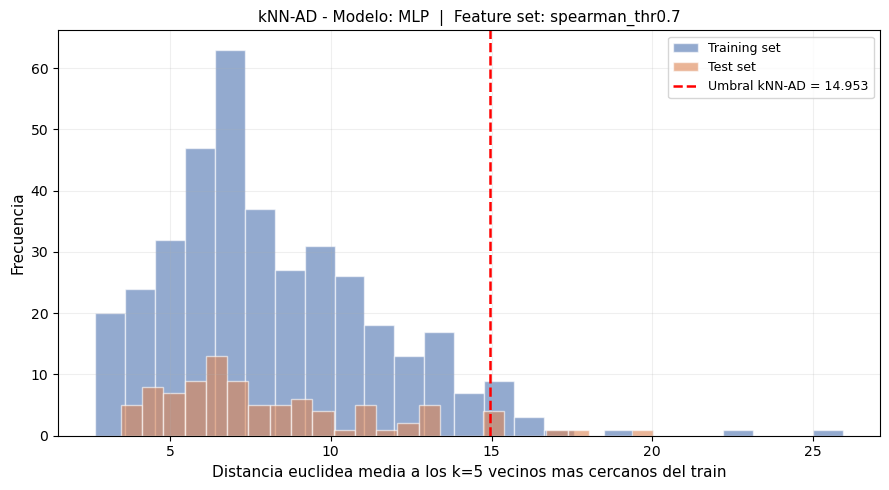

resultados dominio de aplicabilidad mordred/paso8_knnAD_hist_top3_MLP_mordred.png guardado.

-- Test completo (n=92) --
  Accuracy  : 0.7826
  F1        : 0.6970
  MCC       : 0.5283
  ROC-AUC   : 0.8251

-- Test dentro del AD (n=89) --
  Accuracy  : 0.7753
  F1        : 0.6875
  MCC       : 0.5129
  ROC-AUC   : 0.8171

-- Test fuera del AD (n=3) --
  Accuracy  : 1.0000
  F1        : 1.0000
  MCC       : 1.0000
  ROC-AUC   : 1.0000
resultados dominio de aplicabilidad mordred/paso8_ad_metrics_top3_MLP_mordred.csv guardado.

RESUMEN COMPARATIVO - TOP 3 MODELOS (mismo AD, distinto clasificador)
 rank      model     feature_set  roc_auc_all  roc_auc_in_AD  mcc_all  mcc_in_AD
    1   AdaBoost spearman_thr0.7       0.8474         0.8420   0.5703     0.5820
    2 KNeighbors spearman_thr0.7       0.8192         0.8103   0.5500     0.5352
    3        MLP spearman_thr0.7       0.8251         0.8171   0.5283     0.5129

paraso8_summary_top3_maccs.csv guardado.


In [34]:
# =============================================================================
# 8. Dominio de aplicabilidad - kNN-AD (TOP 3 modelos)
# =============================================================================
# Una molecula se considera DENTRO del dominio si esta "cerca" (en el espacio
# de descriptores estandarizado) de las moleculas del training set. Este
# metodo es agnostico al algoritmo de ML: depende solo del feature set, no
# del clasificador.
#
# Algoritmo (kNN-AD):
#   1. Estandarizar los descriptores con la media/SD del TRAIN set.
#   2. Para cada compuesto de train, calcular la distancia euclidea media a
#      sus k=5 vecinos mas cercanos DENTRO DEL PROPIO TRAIN (excluyendo el
#      compuesto consigo mismo, para no inflar artificialmente la distancia
#      media con un cero).
#   3. Umbral = media + 2 x desviacion estandar de esas distancias en train.
#   4. Para cada compuesto de test, calcular su distancia media a los k=5
#      vecinos mas cercanos DEL TRAIN. Si esa distancia < umbral, esta
#      dentro del AD.

def metrics_summary(y_true, y_pred, y_prob, label):
    print(f"\n-- {label} (n={len(y_true)}) --")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  F1        : {f1_score(y_true, y_pred):.4f}")
    print(f"  MCC       : {matthews_corrcoef(y_true, y_pred):.4f}")
    if len(np.unique(y_true)) > 1:
        print(f"  ROC-AUC   : {roc_auc_score(y_true, y_prob):.4f}")
    return {
        'subset'  : label,
        'n'       : len(y_true),
        'accuracy': accuracy_score(y_true, y_pred),
        'f1'      : f1_score(y_true, y_pred),
        'mcc'     : matthews_corrcoef(y_true, y_pred),
        'roc_auc' : roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
    }


def knn_ad(X_train: pd.DataFrame, X_test: pd.DataFrame, n_neighbors: int = 5, z: float = 2.0):
    scaler_ad = StandardScaler()
    X_train_ad = scaler_ad.fit_transform(X_train)
    X_test_ad  = scaler_ad.transform(X_test)

    nn = NearestNeighbors(n_neighbors=n_neighbors + 1)  # +1 porque el propio punto sera su vecino 0 en train
    nn.fit(X_train_ad)

    # Distancias en TRAIN: se excluye la columna 0 (distancia a si mismo = 0)
    distances_train, _ = nn.kneighbors(X_train_ad)
    mean_dist_train = distances_train[:, 1:].mean(axis=1)

    threshold = mean_dist_train.mean() + z * mean_dist_train.std()

    # Distancias en TEST: aqui SI se usan los n_neighbors mas cercanos del
    # train tal cual (el punto de test no esta en el training set, no hay
    # auto-match que excluir). Se reutiliza el mismo objeto nn (ya ajustado
    # con n_neighbors+1) y se descarta la ultima columna para mantener k=5.
    distances_test, _ = nn.kneighbors(X_test_ad)
    mean_dist_test = distances_test[:, :n_neighbors].mean(axis=1)

    return mean_dist_train, mean_dist_test, threshold, scaler_ad, nn


def plot_ad_distance_hist(model_name, mean_dist_train, mean_dist_test, threshold, fs_name, model_tag):
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.hist(mean_dist_train, bins=25, color="#4C72B0", alpha=0.6, edgecolor="white", label="Training set")
    ax.hist(mean_dist_test, bins=25, color="#DD8452", alpha=0.6, edgecolor="white", label="Test set")
    ax.axvline(threshold, color="red", linestyle="--", linewidth=1.8, label=f"Umbral kNN-AD = {threshold:.3f}")
    ax.set_xlabel("Distancia euclidea media a los k=5 vecinos mas cercanos del train", fontsize=11)
    ax.set_ylabel("Frecuencia", fontsize=11)
    ax.set_title(f"kNN-AD - Modelo: {model_name}  |  Feature set: {fs_name}", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    out_hist = f'{OUTPUT_DIR_AD}/paso8_knnAD_hist_{model_tag}_mordred.png'
    plt.savefig(out_hist, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'{out_hist} guardado.')


top3 = df_results.head(3).reset_index(drop=True)

print("=" * 60)
print("TOP 3 MODELOS SELECCIONADOS PARA EL DOMINIO DE APLICABILIDAD (por CV)")
print("=" * 60)
cols_show = ["model", "feature_set", "n_features", "cv_roc_auc_mean", "roc_auc_test"]
print(top3[cols_show].to_string(index=False))
print()

fs_name = best_fs_name   # feature set / threshold ganador (seleccionado en la seccion anterior)
fs_cols = feature_sets[fs_name]
best_key = f"{top3.iloc[0]['model']}__{fs_name}"

# ── kNN-AD: se calcula UNA vez (unico feature set, agnostico al modelo) ─────
mean_dist_train, mean_dist_test, threshold, scaler_ad, nn_ad = knn_ad(
    X_train_full[fs_cols], X_test_full[fs_cols], n_neighbors=5, z=2.0
)

print(f"Descriptores (k)         : {len(fs_cols)}")
print(f"Compuestos train (n)     : {len(X_train_full)}")
print(f"Umbral kNN-AD            : {threshold:.4f}")

mask_ad = mean_dist_test < threshold
print()
print(f"Train - dist. media (mean +/- std): {mean_dist_train.mean():.4f} +/- {mean_dist_train.std():.4f}")
print(f"Test  - dentro del AD    : {mask_ad.sum()} ({mask_ad.mean():.1%})")
print(f"Test  - fuera del AD     : {(~mask_ad).sum()} ({(~mask_ad).mean():.1%})")

# ── Cobertura del AD vs rendimiento del top1, variando el multiplicador z ───
z_values = np.arange(0.5, 5.1, 0.25)
top1_est = best_estimators[best_key]
y_pred_top1 = top1_est.predict(X_test_full[fs_cols])
y_prob_top1 = (top1_est.predict_proba(X_test_full[fs_cols])[:, 1]
               if hasattr(top1_est, "predict_proba")
               else top1_est.decision_function(X_test_full[fs_cols]))

coverages, aucs_cov, mccs_cov = [], [], []
for zval in z_values:
    thr = mean_dist_train.mean() + zval * mean_dist_train.std()
    mask = mean_dist_test < thr
    coverages.append(mask.mean())
    if mask.sum() > 5 and len(np.unique(y_test[mask])) > 1:
        aucs_cov.append(roc_auc_score(y_test[mask], y_prob_top1[mask]))
        mccs_cov.append(matthews_corrcoef(y_test[mask], y_pred_top1[mask]))
    else:
        aucs_cov.append(np.nan)
        mccs_cov.append(np.nan)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot(z_values, coverages, 'o-',  color='#4C72B0', label='Cobertura AD (%)')
ax2.plot(z_values, aucs_cov,  's--', color='#DD8452', label=f'ROC-AUC {top3.iloc[0]["model"]} (dentro AD)')
ax2.plot(z_values, mccs_cov,  '^:',  color='#55A868', label=f'MCC {top3.iloc[0]["model"]} (dentro AD)')
ax1.axvline(2.0, color='red', linestyle='--', linewidth=1, label='multiplicador usado (z=2.0)')
ax1.set_xlabel('Multiplicador z del umbral (mean + z x SD)', fontsize=11)
ax1.set_ylabel('Cobertura (fraccion de compuestos)', fontsize=11, color='#4C72B0')
ax2.set_ylabel('Metrica de rendimiento', fontsize=11, color='#DD8452')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='center right')
ax1.set_title(f'Cobertura del kNN-AD vs Rendimiento - {fs_name}', fontsize=11)
ax1.grid(alpha=0.2)
plt.tight_layout()
out_cov = f'{OUTPUT_DIR_AD}/paso8_ad_coverage_{fs_name}_mordred.png'
plt.savefig(out_cov, dpi=150, bbox_inches='tight')
plt.show()
print(f'{out_cov} guardado.')

# ── Guardar distancia media por compuesto (train + test) ────────────────────
df_ad_train = pd.DataFrame({
    'smiles_std'      : df_mol.iloc[train_idx]['smiles_std'].values,
    'split'           : 'train',
    'mean_dist_5nn'   : mean_dist_train,
    'label'           : y_train.values,
    'in_AD'           : 1,  # por definicion, el training set siempre esta dentro de su propio dominio
    'feature_set'     : fs_name,
})
df_ad_test = pd.DataFrame({
    'smiles_std'      : df_mol.iloc[test_idx]['smiles_std'].values,
    'split'           : 'test',
    'mean_dist_5nn'   : mean_dist_test,
    'label'           : y_test.values,
    'in_AD'           : mask_ad.astype(int),
    'feature_set'     : fs_name,
})
df_ad_all = pd.concat([df_ad_train, df_ad_test], ignore_index=True)
out_dist = f'{OUTPUT_DIR_AD}/paso8_knnAD_{fs_name}_mordred.csv'
df_ad_all.to_csv(out_dist, index=False)
print(df_ad_all.groupby(['split', 'in_AD']).size().rename('n_compuestos').to_string())
print(f'{out_dist} guardado.')

# =============================================================================
# Histograma + rendimiento dentro / fuera del AD, POR CADA UNO de los 3 modelos
# =============================================================================
summary_rows = []
for rank, row in top3.iterrows():
    rank += 1
    model_name = row["model"]
    key        = f"{model_name}__{fs_name}"
    est        = best_estimators[key]
    model_tag  = f"top{rank}_{model_name}"

    print("\n" + "=" * 60)
    print(f"[{rank}/3] MODELO: {model_name}  |  Feature set: {fs_name}")
    print("=" * 60)

    # Histograma de distancias individual para este modelo (mismo criterio
    # kNN-AD, pero figura propia identificada con el nombre del modelo)
    plot_ad_distance_hist(model_name, mean_dist_train, mean_dist_test, threshold, fs_name, model_tag)

    y_pred_test = est.predict(X_test_full[fs_cols])
    y_prob_test = (est.predict_proba(X_test_full[fs_cols])[:, 1]
                   if hasattr(est, "predict_proba")
                   else est.decision_function(X_test_full[fs_cols]))

    r_all = metrics_summary(y_test, y_pred_test, y_prob_test, 'Test completo')
    r_ad  = metrics_summary(y_test[mask_ad], y_pred_test[mask_ad], y_prob_test[mask_ad], 'Test dentro del AD')
    r_out = metrics_summary(y_test[~mask_ad], y_pred_test[~mask_ad], y_prob_test[~mask_ad], 'Test fuera del AD')

    df_ad_metrics = pd.DataFrame([r_all, r_ad, r_out])
    df_ad_metrics['model']       = model_name
    df_ad_metrics['feature_set'] = fs_name
    out_metrics = f'{OUTPUT_DIR_AD}/paso8_ad_metrics_{model_tag}_mordred.csv'
    df_ad_metrics.to_csv(out_metrics, index=False)
    print(f"{out_metrics} guardado.")

    summary_rows.append({
        'rank'          : rank,
        'model'         : model_name,
        'feature_set'   : fs_name,
        'roc_auc_all'   : round(roc_auc_score(y_test, y_prob_test), 4),
        'roc_auc_in_AD' : round(r_ad['roc_auc'], 4) if not np.isnan(r_ad['roc_auc']) else np.nan,
        'mcc_all'       : round(r_all['mcc'], 4),
        'mcc_in_AD'     : round(r_ad['mcc'], 4),
    })

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(f'{OUTPUT_DIR_AD}/paso8_summary_top3_mordred.csv', index=False)
print("\n" + "=" * 60)
print("RESUMEN COMPARATIVO - TOP 3 MODELOS (mismo AD, distinto clasificador)")
print("=" * 60)
print(df_summary.to_string(index=False))
print('\nparaso8_summary_top3_maccs.csv guardado.')


# 5. Interpretabilidad por Permutaciones


[1/3] Permutation importance: AdaBoost | spearman_thr0.7 (154 descriptores)
Top 20 descriptores por importancia (ROC-AUC):
 descriptor  importance_mean  importance_std       effect
       JGI4         0.020419        0.010037 positivo (+)
VSA_EState4         0.018982        0.006690 negativo (-)
     ATSC3s         0.014689        0.004426 negativo (-)
   BCUTd-1l         0.008840        0.007331 positivo (+)
   BCUTc-1h         0.008587        0.003523 negativo (-)
    nFARing         0.006846        0.006327 negativo (-)
EState_VSA2         0.006339        0.013078 positivo (+)
     ATSC2d         0.005916        0.008782 negativo (-)
       JGI8         0.005510        0.004459 positivo (+)
      VE1_A         0.005308        0.004921 positivo (+)
   BalabanJ         0.005088        0.005714 negativo (-)
        nCl         0.004648        0.001355 negativo (-)
 PEOE_VSA11         0.004496        0.002689 negativo (-)
       NaaN         0.004260        0.002197 negativo (-)
  PEOE

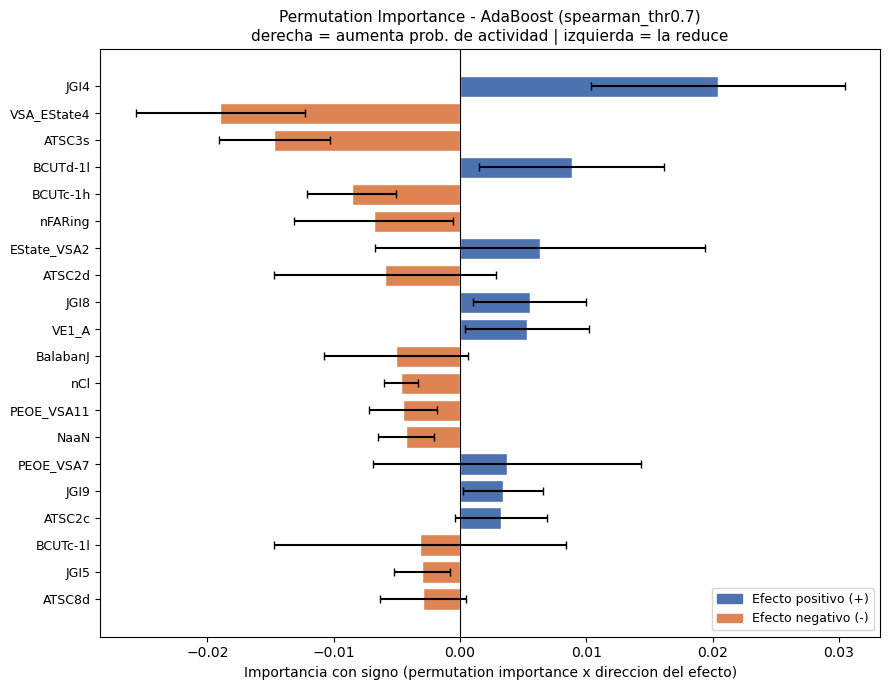

figuras/mordred/paso9_permutation_importance_top1_AdaBoost_mordred.png guardado.

[2/3] Permutation importance: KNeighbors | spearman_thr0.7 (154 descriptores)
Top 20 descriptores por importancia (ROC-AUC):
    descriptor  importance_mean  importance_std       effect
     PEOE_VSA2         0.009652        0.003897 positivo (+)
        ATSC5d         0.009364        0.002958 positivo (+)
        ATSC8d         0.009195        0.004888 negativo (-)
          JGI9         0.008714        0.005522 positivo (+)
        ATSC6c         0.008629        0.005067 negativo (-)
        GATS5d         0.008545        0.004036 negativo (-)
        ATSC5i         0.008494        0.005372 positivo (+)
         NdsCH         0.007606        0.005014 positivo (+)
        Xch-5d         0.007454        0.004482 positivo (+)
       ATSC3se         0.007446        0.006097 positivo (+)
        ATSC8i         0.007378        0.004435 positivo (+)
        ATSC3c         0.007226        0.004722 positivo (+)


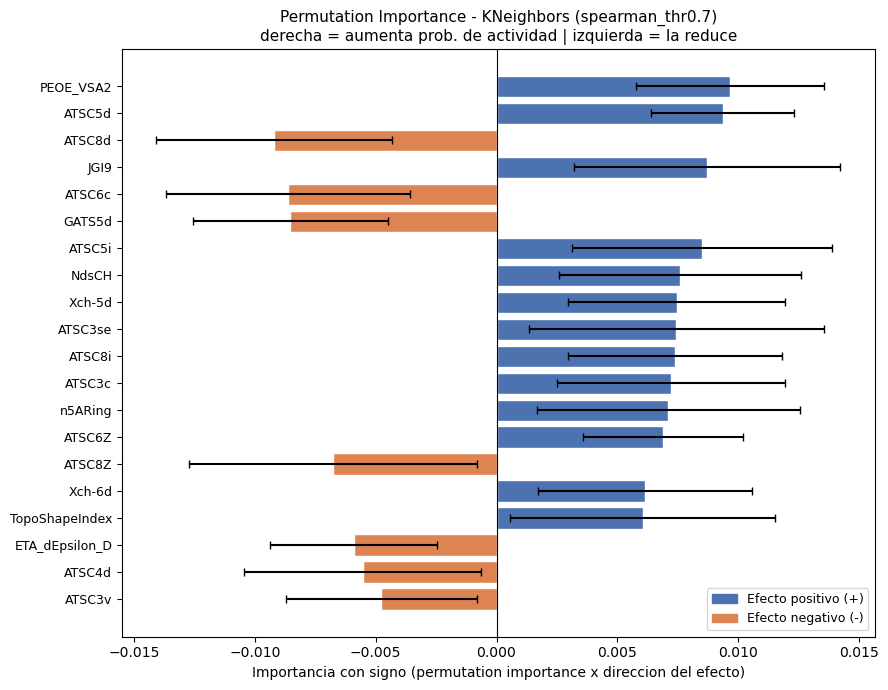

figuras/mordred/paso9_permutation_importance_top2_KNeighbors_mordred.png guardado.

[3/3] Permutation importance: MLP | spearman_thr0.7 (154 descriptores)
Top 20 descriptores por importancia (ROC-AUC):
descriptor  importance_mean  importance_std       effect
     VE1_A         0.021738        0.006750 positivo (+)
    GATS3Z         0.021247        0.005272 positivo (+)
   nFARing         0.012728        0.006979 negativo (-)
   ATSC3se         0.011951        0.003649 positivo (+)
     NaaaC         0.011917        0.004571 positivo (+)
PEOE_VSA11         0.010497        0.007263 negativo (-)
    ATSC1v         0.008976        0.005105 negativo (-)
     NaasN         0.008705        0.003499 negativo (-)
    AATS7i         0.008367        0.006959 negativo (-)
   n6HRing         0.008333        0.003350 positivo (+)
   n5ARing         0.007623        0.003885 positivo (+)
       ABC         0.007268        0.004475 positivo (+)
      NaaN         0.007235        0.004543 negativo (-)


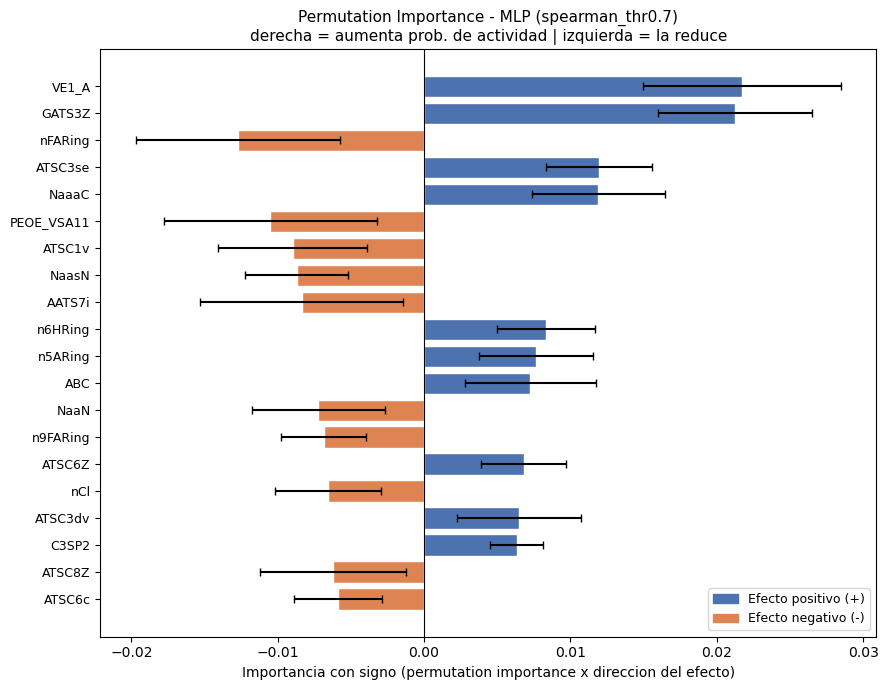

figuras/mordred/paso9_permutation_importance_top3_MLP_mordred.png guardado.

paraso9_permutation_importance_all.csv guardado con la importancia de los TOP 3 modelos del feature set ganador (spearman_thr0.7).


In [35]:

# La importancia por permutacion mide cuanto empeora el rendimiento del
# modelo (ROC-AUC) al barajar aleatoriamente los valores de un descriptor,
# rompiendo su relacion con la actividad. Se calcula sobre el TEST SET (no
# sobre train), para que refleje la contribucion real del descriptor a la
# capacidad de generalizacion, no a su ajuste a los datos de entrenamiento.
#
# La importancia por permutacion solo mide MAGNITUD (cuanto importa), no
# DIRECCION (si el descriptor favorece o penaliza la actividad). Para
# estimar la direccion se calcula la correlacion de Pearson entre el valor
# del descriptor y la probabilidad predicha por el propio modelo en el test
# set: correlacion positiva -> el descriptor aumenta la probabilidad de
# actividad; correlacion negativa -> la reduce. Es una aproximacion (no
# capta relaciones no monotonas), pero es el criterio habitual en QSAR
# cuando se usan modelos no lineales que no tienen coeficientes directos.
#
# En el grafico, la barra se dibuja hacia la DERECHA si el descriptor tiene
# efecto positivo sobre la actividad y hacia la IZQUIERDA si tiene efecto
# negativo (importancia con signo = importancia * signo de la correlacion).
#
# Se reutilizan los mismos TOP 3 modelos (top3) y el mismo feature set
# ganador (best_fs_name / fs_cols) ya seleccionados en la seccion anterior.

N_TOP_DESCRIPTORS = 20
N_REPEATS_PI       = 30

def permutation_importance_report(model_name, est, fs_name, feat_cols, X_te, y_te,
                                   n_repeats=N_REPEATS_PI, random_state=42):
    result = permutation_importance(
        est, X_te[feat_cols], y_te,
        scoring="roc_auc",
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=-1,
    )

    if hasattr(est, "predict_proba"):
        y_prob = est.predict_proba(X_te[feat_cols])[:, 1]
    else:
        y_prob = est.decision_function(X_te[feat_cols])

    directions = []
    for col in feat_cols:
        col_vals = X_te[col].values
        if np.std(col_vals) == 0:
            directions.append(0.0)
        else:
            r, _ = pearsonr(col_vals, y_prob)
            directions.append(r)

    imp_df = pd.DataFrame({
        "descriptor"     : feat_cols,
        "importance_mean": result.importances_mean,
        "importance_std" : result.importances_std,
        "direction_corr" : directions,
    })
    imp_df["sign"] = np.where(imp_df["direction_corr"] >= 0, 1, -1)
    imp_df["signed_importance"] = imp_df["importance_mean"] * imp_df["sign"]
    imp_df["effect"] = np.where(imp_df["direction_corr"] >= 0, "positivo (+)", "negativo (-)")
    imp_df = imp_df.reindex(
        imp_df["importance_mean"].sort_values(ascending=False).index
    ).reset_index(drop=True)
    imp_df.insert(0, "model", model_name)
    imp_df.insert(1, "feature_set", fs_name)
    return imp_df


all_importance_dfs = []

for rank, row in top3.iterrows():
    rank += 1
    model_name = row["model"]
    key        = f"{model_name}__{best_fs_name}"
    est        = best_estimators[key]

    print("\n" + "=" * 60)
    print(f"[{rank}/3] Permutation importance: {model_name} | {best_fs_name} ({len(fs_cols)} descriptores)")
    print("=" * 60)

    imp_df = permutation_importance_report(model_name, est, best_fs_name, fs_cols, X_test_full, y_test)
    all_importance_dfs.append(imp_df)

    top_n = imp_df.head(N_TOP_DESCRIPTORS)
    out_csv = f'{OUTPUT_DIR_INT}/paso9_permutation_importance_top{rank}_{model_name}.csv'
    imp_df.to_csv(out_csv, index=False)
    print(f"Top {N_TOP_DESCRIPTORS} descriptores por importancia (ROC-AUC):")
    print(top_n[["descriptor", "importance_mean", "importance_std", "effect"]].to_string(index=False))
    print(f"{out_csv} guardado.")

    # Orden visual: de mayor a menor importancia absoluta, de arriba a abajo
    top_n_plot = top_n.iloc[::-1]
    colors = np.where(top_n_plot["sign"] > 0, "#4C72B0", "#DD8452")

    fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(top_n_plot))))
    y_pos = np.arange(len(top_n_plot))
    ax.barh(y_pos, top_n_plot["signed_importance"],
            xerr=top_n_plot["importance_std"],
            color=colors, edgecolor="white", capsize=3)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_n_plot["descriptor"], fontsize=9)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Importancia con signo (permutation importance x direccion del efecto)")
    ax.set_title(f"Permutation Importance - {model_name} ({best_fs_name})\n"
                 f"derecha = aumenta prob. de actividad | izquierda = la reduce", fontsize=11)
    legend_patches = [
        plt.Rectangle((0, 0), 1, 1, color="#4C72B0", label="Efecto positivo (+)"),
        plt.Rectangle((0, 0), 1, 1, color="#DD8452", label="Efecto negativo (-)"),
    ]
    ax.legend(handles=legend_patches, loc="lower right", fontsize=9)
    plt.tight_layout()
    out_png = f'{FIGURAS}/paso9_permutation_importance_top{rank}_{model_name}_mordred.png'
    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"{out_png} guardado.")

df_importance_all = pd.concat(all_importance_dfs, ignore_index=True)
df_importance_all.to_csv(f'{OUTPUT_DIR_INT}/paso9_permutation_importance_all.csv', index=False)
print(f"\nparaso9_permutation_importance_all.csv guardado con la importancia de los TOP 3 modelos "
      f"del feature set ganador ({best_fs_name}).")
